In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load real and synthetic datasets
real_data = datasets.ImageFolder(root='/content/drive/MyDrive/trainvehicle', transform=real_data_transform)
synthetic_data = datasets.ImageFolder(root='/content/drive/MyDrive/vehicle_dataset', transform=augmentation_transform)

# Split real data into train and validation sets (80% train, 20% val)
train_size = int(0.8 * len(real_data))
val_size = len(real_data) - train_size
real_train_data, real_val_data = random_split(real_data, [train_size, val_size])

# Define DataLoaders
batch_size = 32
train_loader_real = DataLoader(real_train_data, batch_size=batch_size, shuffle=True)
val_loader_real = DataLoader(real_val_data, batch_size=batch_size, shuffle=False)
train_loader_synthetic = DataLoader(synthetic_data, batch_size=batch_size, shuffle=True)


In [ ]:
# Hybrid dataset combining real and synthetic data
hybrid_data = ConcatDataset([real_train_data, synthetic_data])
train_loader_hybrid = DataLoader(hybrid_data, batch_size=batch_size, shuffle=True)


In [ ]:
# Using ResNet-18 pretrained on ImageNet
model = models.resnet18(pretrained=True)

# Modify the final layer to match the number of vehicle classes
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]


In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Training on Real Data...


Epoch [1/20] on Real Data: 100%|██████████| 35/35 [03:23<00:00,  5.82s/it, Loss=0.8534, Accuracy=71.07%]


Epoch [1/20] on Real Data, Loss: 0.8534, Accuracy: 71.07%
Validation Accuracy on Real Data: 67.08%
              precision    recall  f1-score   support

         SUV       0.59      0.91      0.71        22
         bus       0.83      0.62      0.71        24
family sedan       0.56      0.60      0.58        25
 fire engine       1.00      0.50      0.67        22
 heavy truck       0.75      0.69      0.72        26
        jeep       0.51      0.83      0.63        24
     minibus       1.00      0.50      0.67        28
  racing car       0.56      0.74      0.64        19
        taxi       0.83      0.54      0.65        28
       truck       0.63      0.86      0.73        22

    accuracy                           0.67       240
   macro avg       0.73      0.68      0.67       240
weighted avg       0.74      0.67      0.67       240



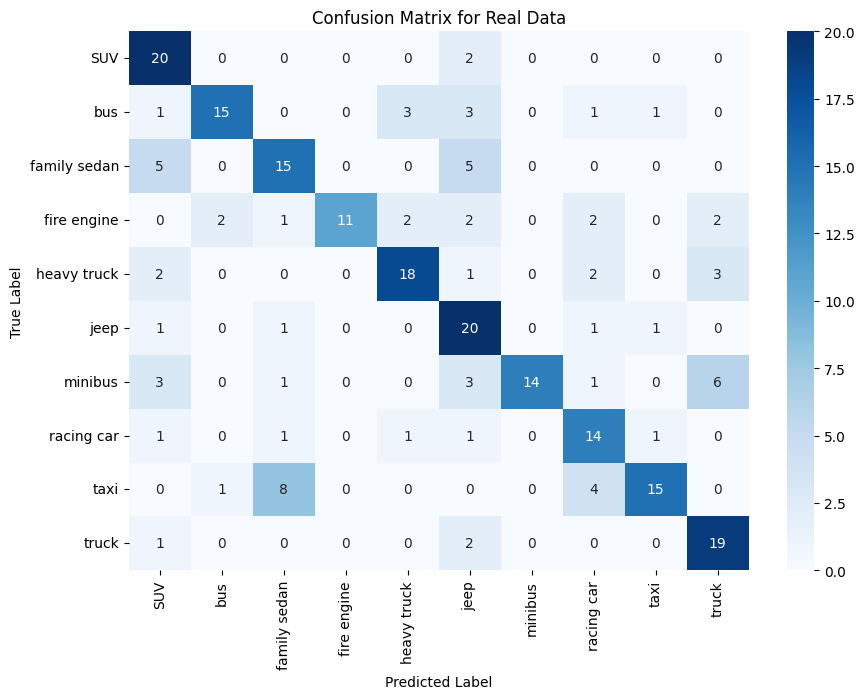

Epoch [2/20] on Real Data: 100%|██████████| 35/35 [00:33<00:00,  1.04it/s, Loss=0.4085, Accuracy=86.96%]


Epoch [2/20] on Real Data, Loss: 0.4085, Accuracy: 86.96%
Validation Accuracy on Real Data: 62.50%
              precision    recall  f1-score   support

         SUV       0.87      0.91      0.89        22
         bus       0.58      0.92      0.71        24
family sedan       0.50      0.08      0.14        25
 fire engine       0.89      0.77      0.83        22
 heavy truck       0.57      0.92      0.71        26
        jeep       0.60      0.12      0.21        24
     minibus       0.82      0.50      0.62        28
  racing car       0.42      0.95      0.58        19
        taxi       0.92      0.39      0.55        28
       truck       0.51      0.86      0.64        22

    accuracy                           0.62       240
   macro avg       0.67      0.64      0.59       240
weighted avg       0.68      0.62      0.58       240



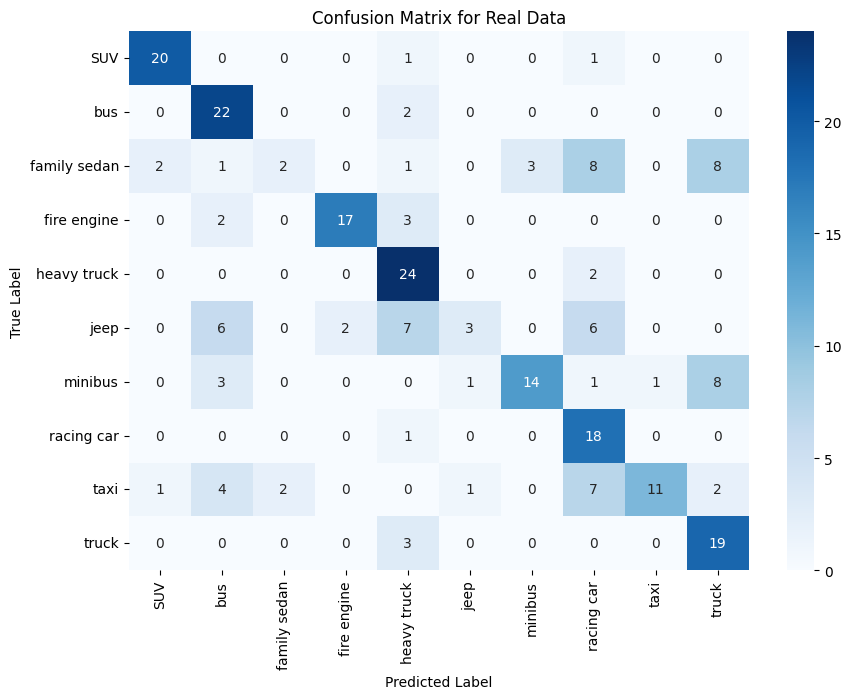

Epoch [3/20] on Real Data: 100%|██████████| 35/35 [00:33<00:00,  1.04it/s, Loss=0.3254, Accuracy=89.29%]


Epoch [3/20] on Real Data, Loss: 0.3254, Accuracy: 89.29%
Validation Accuracy on Real Data: 60.42%
              precision    recall  f1-score   support

         SUV       1.00      0.18      0.31        22
         bus       1.00      0.79      0.88        24
family sedan       0.26      1.00      0.41        25
 fire engine       1.00      0.73      0.84        22
 heavy truck       0.85      0.65      0.74        26
        jeep       1.00      0.38      0.55        24
     minibus       1.00      0.21      0.35        28
  racing car       0.53      0.89      0.67        19
        taxi       0.76      0.46      0.58        28
       truck       0.95      0.86      0.90        22

    accuracy                           0.60       240
   macro avg       0.84      0.62      0.62       240
weighted avg       0.84      0.60      0.62       240



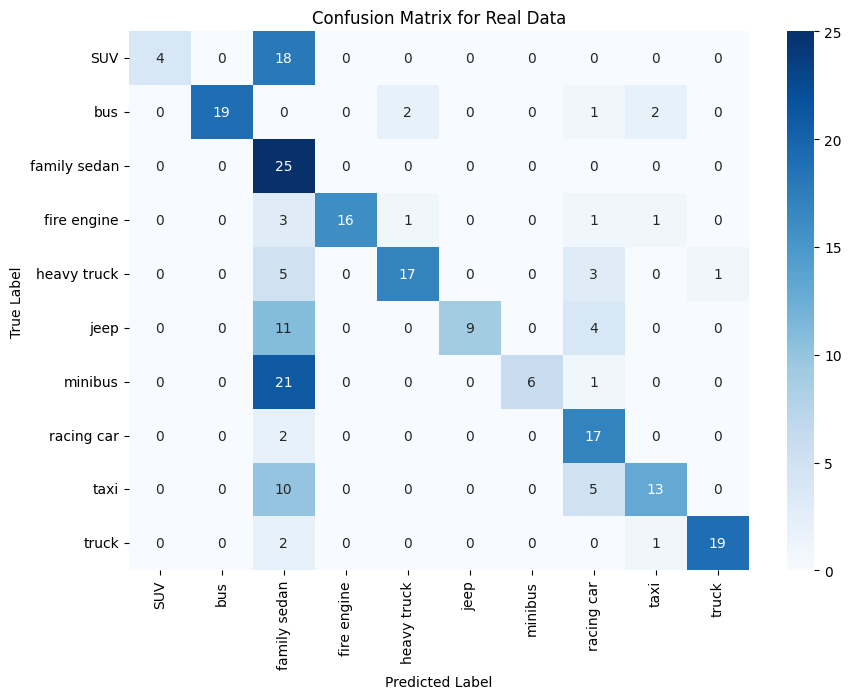

Epoch [4/20] on Real Data: 100%|██████████| 35/35 [00:33<00:00,  1.05it/s, Loss=0.2227, Accuracy=93.21%]


Epoch [4/20] on Real Data, Loss: 0.2227, Accuracy: 93.21%
Validation Accuracy on Real Data: 84.17%
              precision    recall  f1-score   support

         SUV       0.86      0.82      0.84        22
         bus       0.86      1.00      0.92        24
family sedan       0.91      0.80      0.85        25
 fire engine       1.00      0.64      0.78        22
 heavy truck       0.83      0.73      0.78        26
        jeep       0.94      0.71      0.81        24
     minibus       0.78      0.89      0.83        28
  racing car       0.82      0.95      0.88        19
        taxi       0.90      0.93      0.91        28
       truck       0.68      0.95      0.79        22

    accuracy                           0.84       240
   macro avg       0.86      0.84      0.84       240
weighted avg       0.86      0.84      0.84       240



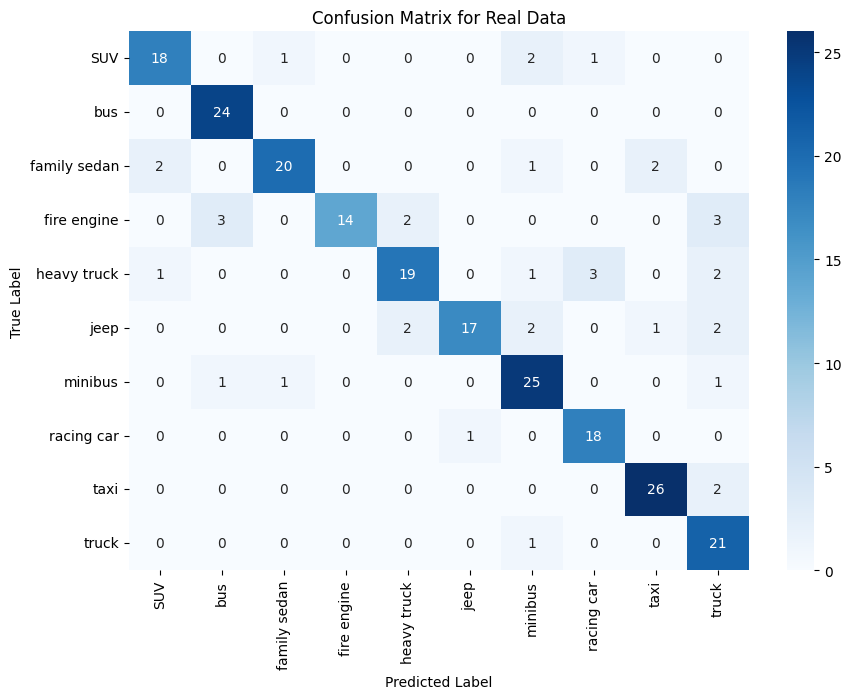

Epoch [5/20] on Real Data: 100%|██████████| 35/35 [00:33<00:00,  1.05it/s, Loss=0.1786, Accuracy=93.93%]


Epoch [5/20] on Real Data, Loss: 0.1786, Accuracy: 93.93%
Validation Accuracy on Real Data: 77.92%
              precision    recall  f1-score   support

         SUV       0.70      0.95      0.81        22
         bus       0.96      0.92      0.94        24
family sedan       0.62      0.80      0.70        25
 fire engine       1.00      0.68      0.81        22
 heavy truck       0.81      0.81      0.81        26
        jeep       0.52      0.96      0.68        24
     minibus       0.95      0.75      0.84        28
  racing car       0.92      0.63      0.75        19
        taxi       1.00      0.39      0.56        28
       truck       0.88      0.95      0.91        22

    accuracy                           0.78       240
   macro avg       0.84      0.78      0.78       240
weighted avg       0.84      0.78      0.78       240



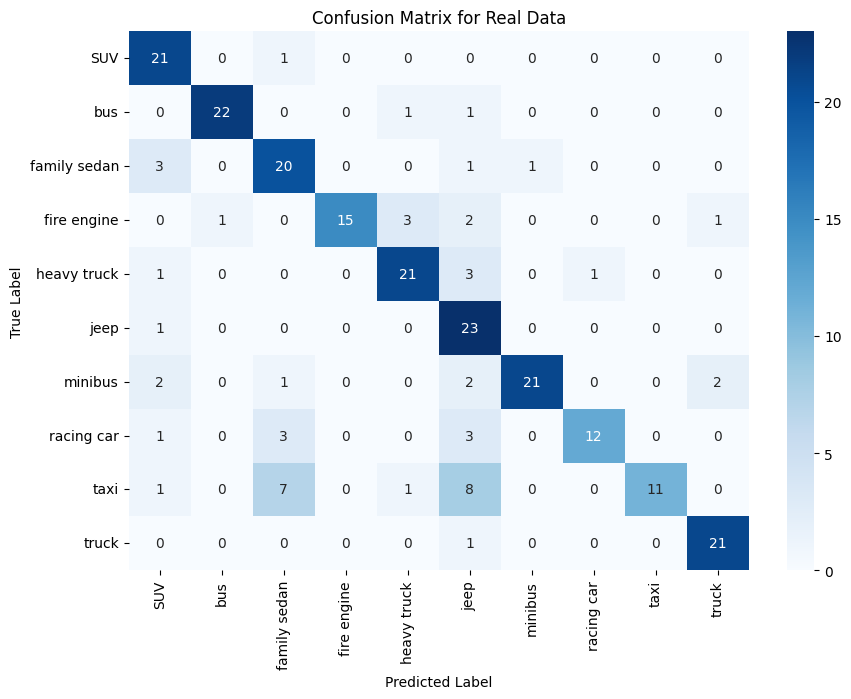

Epoch [6/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.07it/s, Loss=0.2070, Accuracy=93.48%]


Epoch [6/20] on Real Data, Loss: 0.2070, Accuracy: 93.48%
Validation Accuracy on Real Data: 75.42%
              precision    recall  f1-score   support

         SUV       0.87      0.91      0.89        22
         bus       0.96      0.92      0.94        24
family sedan       0.73      0.76      0.75        25
 fire engine       0.51      0.91      0.66        22
 heavy truck       0.88      0.85      0.86        26
        jeep       1.00      0.33      0.50        24
     minibus       0.94      0.54      0.68        28
  racing car       0.57      0.84      0.68        19
        taxi       0.77      0.71      0.74        28
       truck       0.73      0.86      0.79        22

    accuracy                           0.75       240
   macro avg       0.80      0.76      0.75       240
weighted avg       0.81      0.75      0.75       240



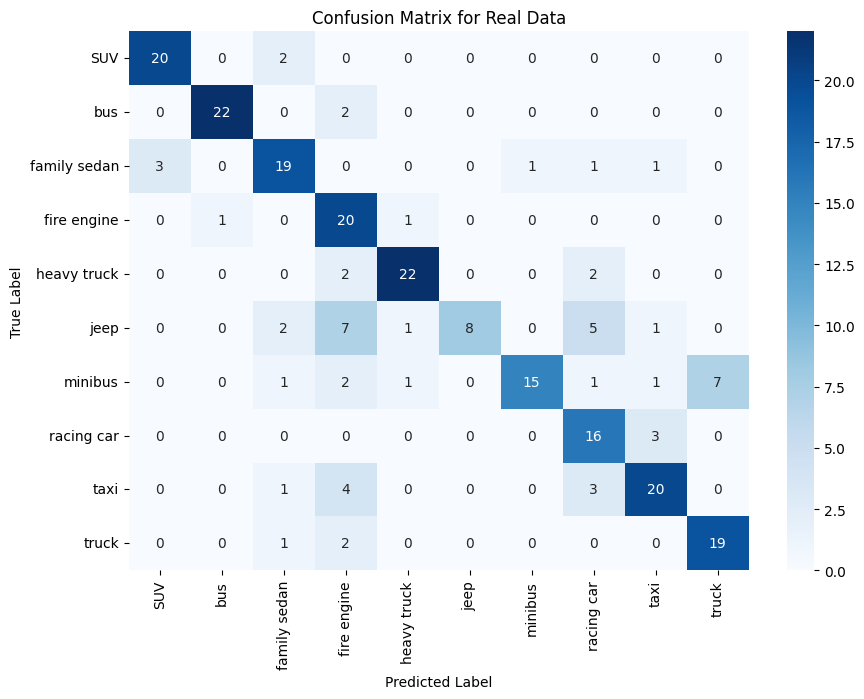

Epoch [7/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.07it/s, Loss=0.1674, Accuracy=94.55%]


Epoch [7/20] on Real Data, Loss: 0.1674, Accuracy: 94.55%
Validation Accuracy on Real Data: 78.33%
              precision    recall  f1-score   support

         SUV       0.90      0.86      0.88        22
         bus       1.00      0.75      0.86        24
family sedan       0.55      0.96      0.70        25
 fire engine       0.84      0.73      0.78        22
 heavy truck       0.85      0.88      0.87        26
        jeep       0.77      0.96      0.85        24
     minibus       0.84      0.57      0.68        28
  racing car       1.00      0.53      0.69        19
        taxi       0.83      0.71      0.77        28
       truck       0.68      0.86      0.76        22

    accuracy                           0.78       240
   macro avg       0.83      0.78      0.78       240
weighted avg       0.82      0.78      0.78       240



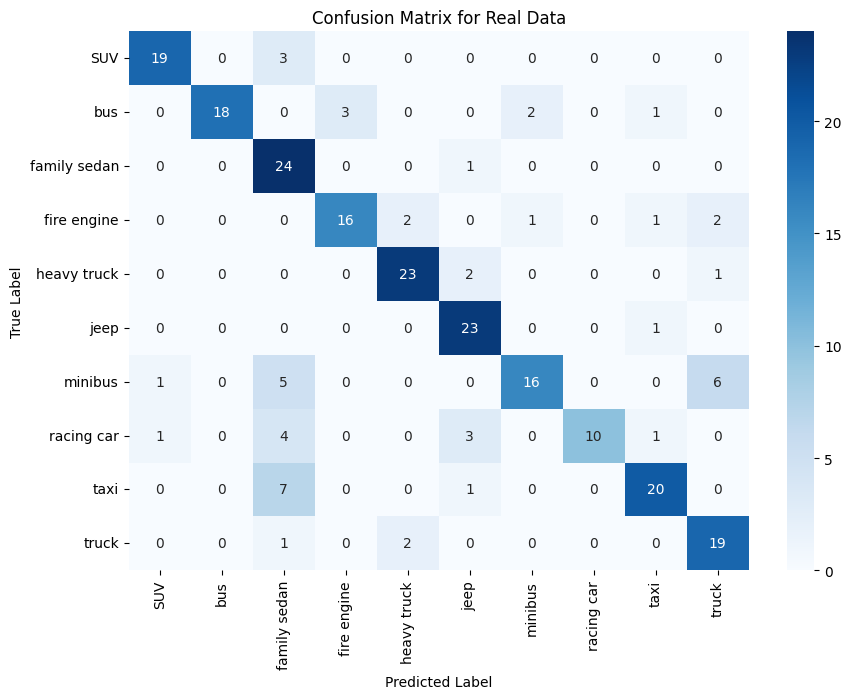

Epoch [8/20] on Real Data: 100%|██████████| 35/35 [00:33<00:00,  1.05it/s, Loss=0.1616, Accuracy=94.82%]


Epoch [8/20] on Real Data, Loss: 0.1616, Accuracy: 94.82%
Validation Accuracy on Real Data: 72.08%
              precision    recall  f1-score   support

         SUV       0.80      0.91      0.85        22
         bus       0.65      1.00      0.79        24
family sedan       0.87      0.52      0.65        25
 fire engine       1.00      0.50      0.67        22
 heavy truck       0.52      0.92      0.67        26
        jeep       0.90      0.79      0.84        24
     minibus       0.88      0.25      0.39        28
  racing car       0.71      0.89      0.79        19
        taxi       0.71      0.89      0.79        28
       truck       0.72      0.59      0.65        22

    accuracy                           0.72       240
   macro avg       0.78      0.73      0.71       240
weighted avg       0.77      0.72      0.70       240



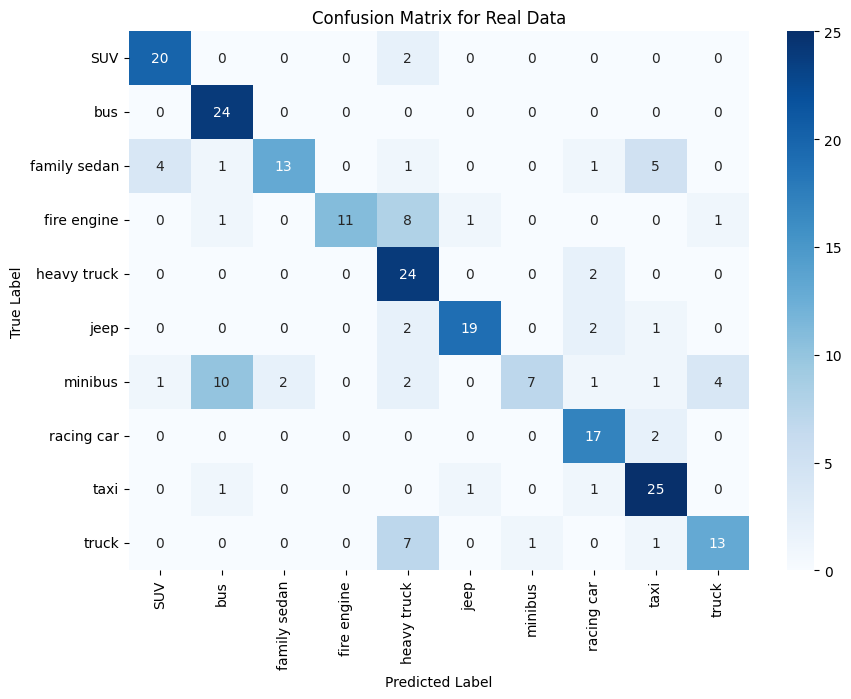

Epoch [9/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.07it/s, Loss=0.1374, Accuracy=95.62%]


Epoch [9/20] on Real Data, Loss: 0.1374, Accuracy: 95.62%
Validation Accuracy on Real Data: 79.17%
              precision    recall  f1-score   support

         SUV       0.94      0.73      0.82        22
         bus       0.95      0.79      0.86        24
family sedan       0.44      0.96      0.60        25
 fire engine       0.89      0.73      0.80        22
 heavy truck       0.92      0.85      0.88        26
        jeep       0.88      0.88      0.88        24
     minibus       0.92      0.82      0.87        28
  racing car       0.83      0.79      0.81        19
        taxi       0.83      0.54      0.65        28
       truck       0.90      0.86      0.88        22

    accuracy                           0.79       240
   macro avg       0.85      0.79      0.81       240
weighted avg       0.85      0.79      0.80       240



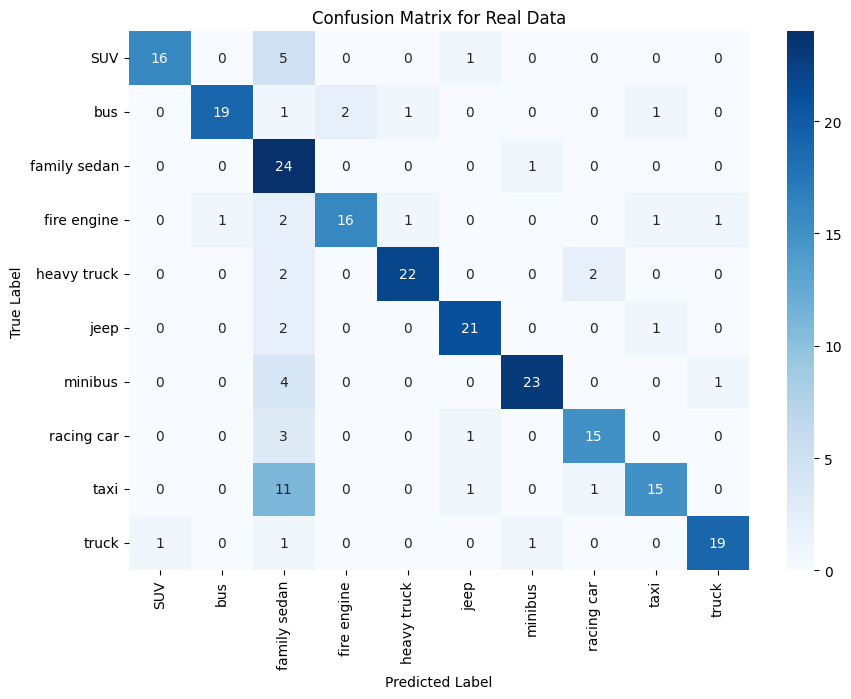

Epoch [10/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.09it/s, Loss=0.1047, Accuracy=95.80%]


Epoch [10/20] on Real Data, Loss: 0.1047, Accuracy: 95.80%
Validation Accuracy on Real Data: 79.17%
              precision    recall  f1-score   support

         SUV       0.70      0.86      0.78        22
         bus       0.96      1.00      0.98        24
family sedan       0.51      0.92      0.66        25
 fire engine       0.94      0.73      0.82        22
 heavy truck       0.91      0.81      0.86        26
        jeep       0.77      0.71      0.74        24
     minibus       1.00      0.71      0.83        28
  racing car       1.00      0.42      0.59        19
        taxi       0.85      0.82      0.84        28
       truck       0.73      0.86      0.79        22

    accuracy                           0.79       240
   macro avg       0.84      0.78      0.79       240
weighted avg       0.84      0.79      0.79       240



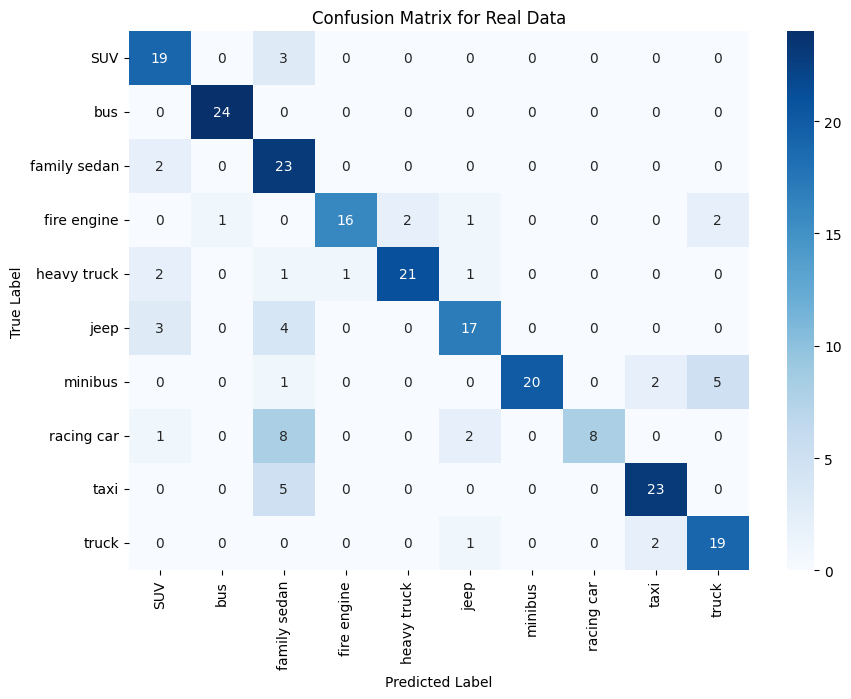

Epoch [11/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.06it/s, Loss=0.0970, Accuracy=96.70%]


Epoch [11/20] on Real Data, Loss: 0.0970, Accuracy: 96.70%
Validation Accuracy on Real Data: 85.42%
              precision    recall  f1-score   support

         SUV       0.95      0.82      0.88        22
         bus       1.00      0.96      0.98        24
family sedan       0.80      0.80      0.80        25
 fire engine       0.95      0.82      0.88        22
 heavy truck       0.96      0.88      0.92        26
        jeep       1.00      0.71      0.83        24
     minibus       0.86      0.86      0.86        28
  racing car       0.77      0.89      0.83        19
        taxi       0.79      0.93      0.85        28
       truck       0.63      0.86      0.73        22

    accuracy                           0.85       240
   macro avg       0.87      0.85      0.86       240
weighted avg       0.87      0.85      0.86       240



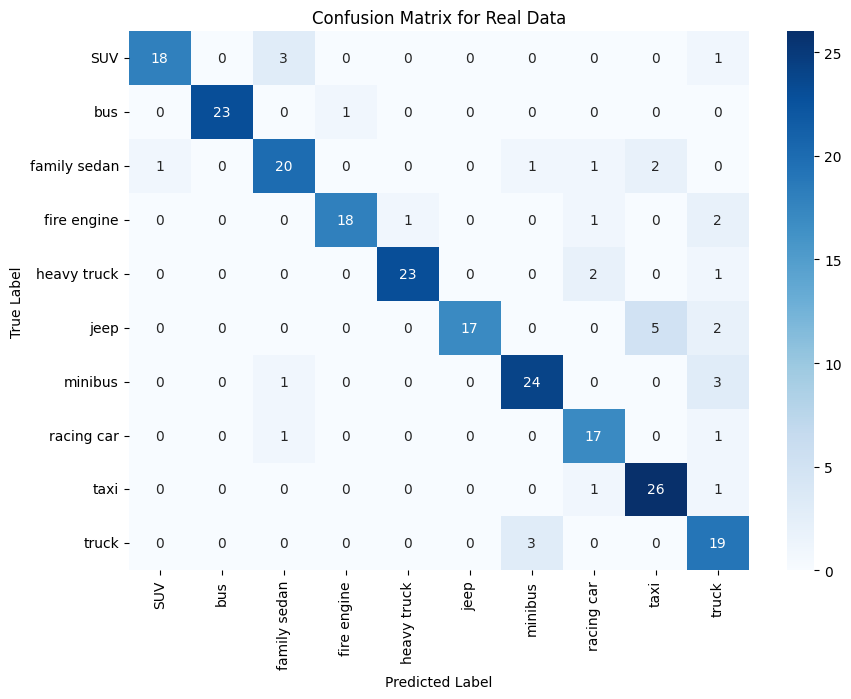

Epoch [12/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.09it/s, Loss=0.0702, Accuracy=97.95%]


Epoch [12/20] on Real Data, Loss: 0.0702, Accuracy: 97.95%
Validation Accuracy on Real Data: 82.08%
              precision    recall  f1-score   support

         SUV       0.84      0.95      0.89        22
         bus       0.95      0.83      0.89        24
family sedan       0.59      0.80      0.68        25
 fire engine       0.88      0.68      0.77        22
 heavy truck       0.92      0.92      0.92        26
        jeep       0.73      1.00      0.84        24
     minibus       0.89      0.89      0.89        28
  racing car       0.87      0.68      0.76        19
        taxi       1.00      0.54      0.70        28
       truck       0.77      0.91      0.83        22

    accuracy                           0.82       240
   macro avg       0.84      0.82      0.82       240
weighted avg       0.85      0.82      0.82       240



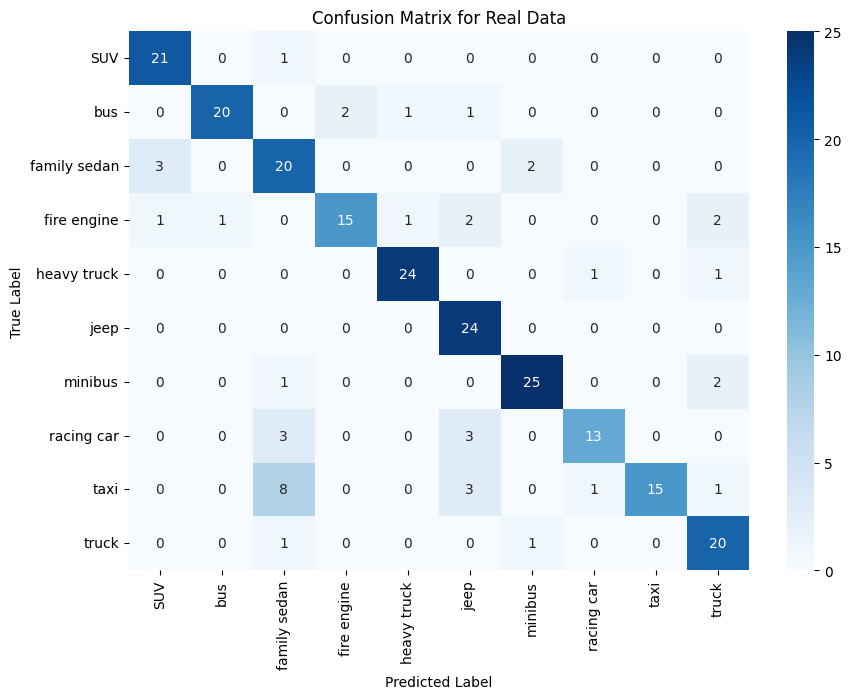

Epoch [13/20] on Real Data: 100%|██████████| 35/35 [00:31<00:00,  1.10it/s, Loss=0.0657, Accuracy=97.95%]


Epoch [13/20] on Real Data, Loss: 0.0657, Accuracy: 97.95%
Validation Accuracy on Real Data: 83.33%
              precision    recall  f1-score   support

         SUV       1.00      0.32      0.48        22
         bus       0.92      0.92      0.92        24
family sedan       0.67      0.88      0.76        25
 fire engine       0.83      0.86      0.84        22
 heavy truck       0.92      0.88      0.90        26
        jeep       0.95      0.88      0.91        24
     minibus       0.82      0.82      0.82        28
  racing car       1.00      0.79      0.88        19
        taxi       0.82      0.96      0.89        28
       truck       0.70      0.95      0.81        22

    accuracy                           0.83       240
   macro avg       0.86      0.83      0.82       240
weighted avg       0.86      0.83      0.82       240



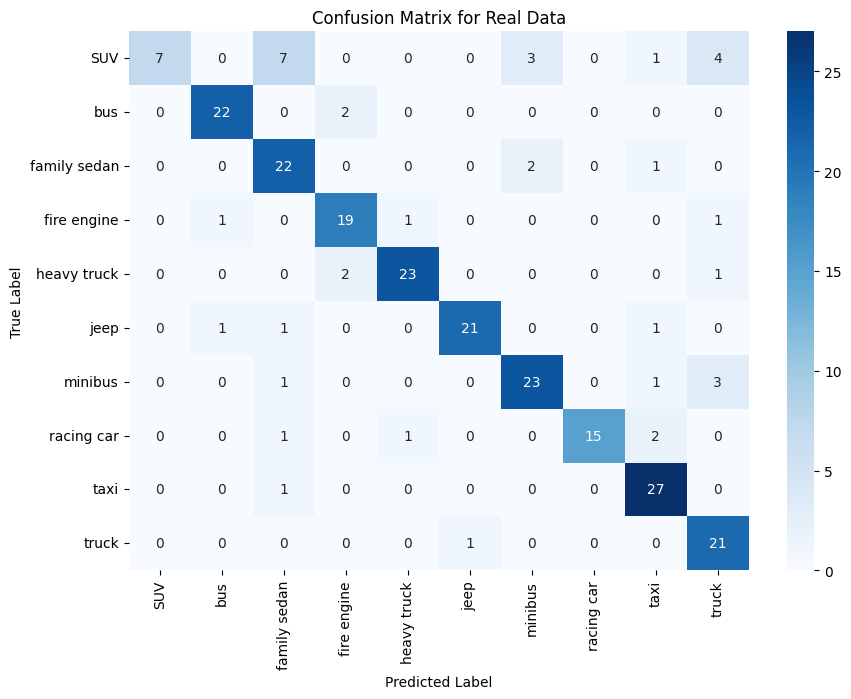

Epoch [14/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.07it/s, Loss=0.0501, Accuracy=98.57%]


Epoch [14/20] on Real Data, Loss: 0.0501, Accuracy: 98.57%
Validation Accuracy on Real Data: 87.92%
              precision    recall  f1-score   support

         SUV       0.91      0.91      0.91        22
         bus       0.96      0.92      0.94        24
family sedan       0.91      0.84      0.88        25
 fire engine       0.89      0.77      0.83        22
 heavy truck       0.84      0.81      0.82        26
        jeep       1.00      0.92      0.96        24
     minibus       0.93      0.89      0.91        28
  racing car       0.64      0.95      0.77        19
        taxi       0.93      0.89      0.91        28
       truck       0.83      0.91      0.87        22

    accuracy                           0.88       240
   macro avg       0.88      0.88      0.88       240
weighted avg       0.89      0.88      0.88       240



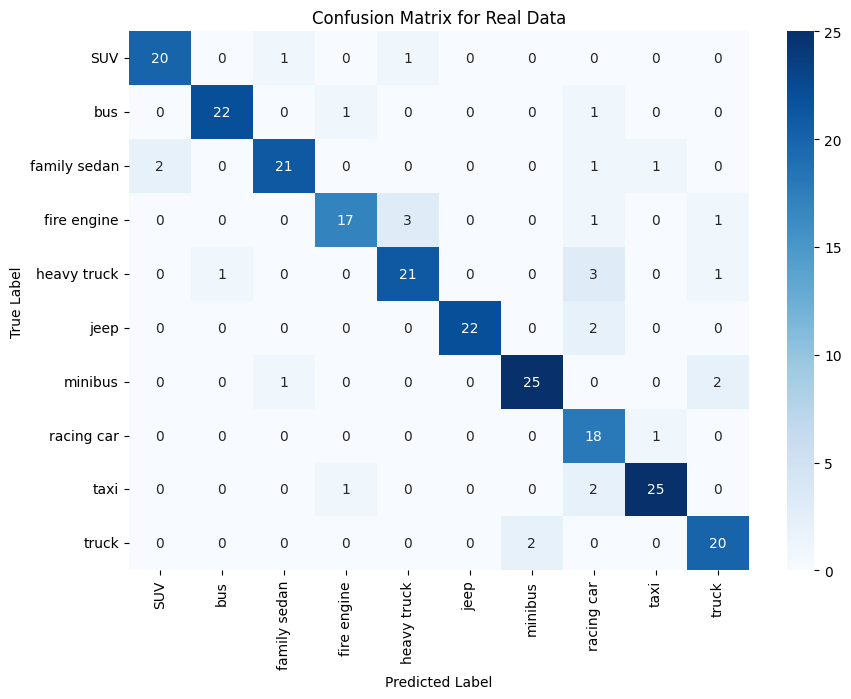

Epoch [15/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.08it/s, Loss=0.0615, Accuracy=98.48%]


Epoch [15/20] on Real Data, Loss: 0.0615, Accuracy: 98.48%
Validation Accuracy on Real Data: 87.50%
              precision    recall  f1-score   support

         SUV       0.88      0.95      0.91        22
         bus       0.92      1.00      0.96        24
family sedan       0.84      0.84      0.84        25
 fire engine       1.00      0.77      0.87        22
 heavy truck       0.92      0.85      0.88        26
        jeep       0.79      0.96      0.87        24
     minibus       0.81      0.93      0.87        28
  racing car       0.80      0.84      0.82        19
        taxi       1.00      0.82      0.90        28
       truck       0.85      0.77      0.81        22

    accuracy                           0.88       240
   macro avg       0.88      0.87      0.87       240
weighted avg       0.88      0.88      0.87       240



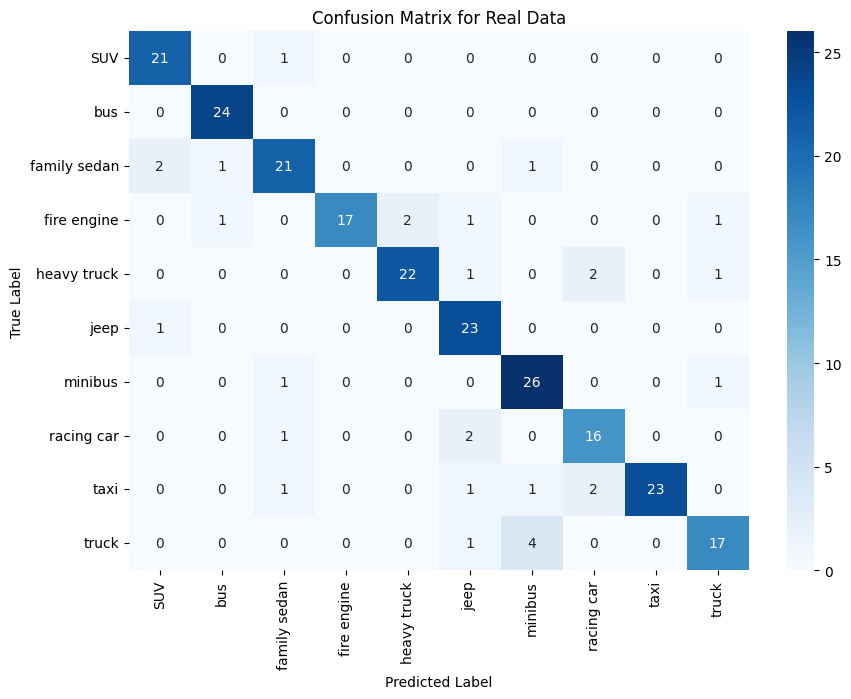

Epoch [16/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.09it/s, Loss=0.0783, Accuracy=97.86%]


Epoch [16/20] on Real Data, Loss: 0.0783, Accuracy: 97.86%
Validation Accuracy on Real Data: 81.67%
              precision    recall  f1-score   support

         SUV       0.57      0.95      0.71        22
         bus       0.92      0.92      0.92        24
family sedan       0.72      0.84      0.78        25
 fire engine       0.81      0.77      0.79        22
 heavy truck       0.91      0.81      0.86        26
        jeep       0.85      0.92      0.88        24
     minibus       0.88      0.75      0.81        28
  racing car       0.86      1.00      0.93        19
        taxi       0.95      0.71      0.82        28
       truck       0.92      0.55      0.69        22

    accuracy                           0.82       240
   macro avg       0.84      0.82      0.82       240
weighted avg       0.84      0.82      0.82       240



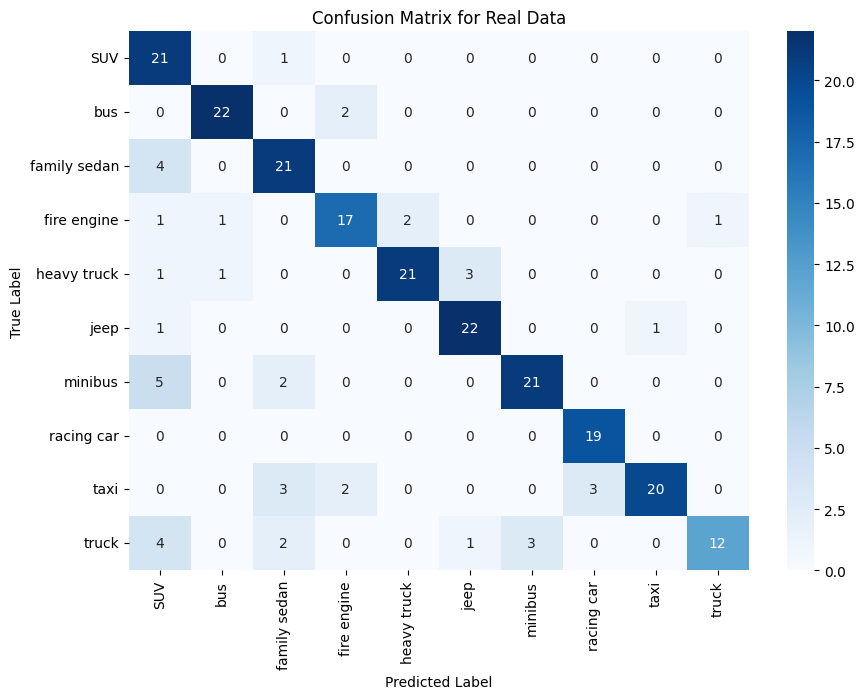

Epoch [17/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.07it/s, Loss=0.0729, Accuracy=97.23%]


Epoch [17/20] on Real Data, Loss: 0.0729, Accuracy: 97.23%
Validation Accuracy on Real Data: 85.42%
              precision    recall  f1-score   support

         SUV       0.83      0.91      0.87        22
         bus       0.96      0.92      0.94        24
family sedan       0.77      0.80      0.78        25
 fire engine       0.71      0.91      0.80        22
 heavy truck       0.82      0.88      0.85        26
        jeep       0.96      1.00      0.98        24
     minibus       1.00      0.61      0.76        28
  racing car       0.72      0.95      0.82        19
        taxi       0.96      0.79      0.86        28
       truck       0.90      0.86      0.88        22

    accuracy                           0.85       240
   macro avg       0.86      0.86      0.85       240
weighted avg       0.87      0.85      0.85       240



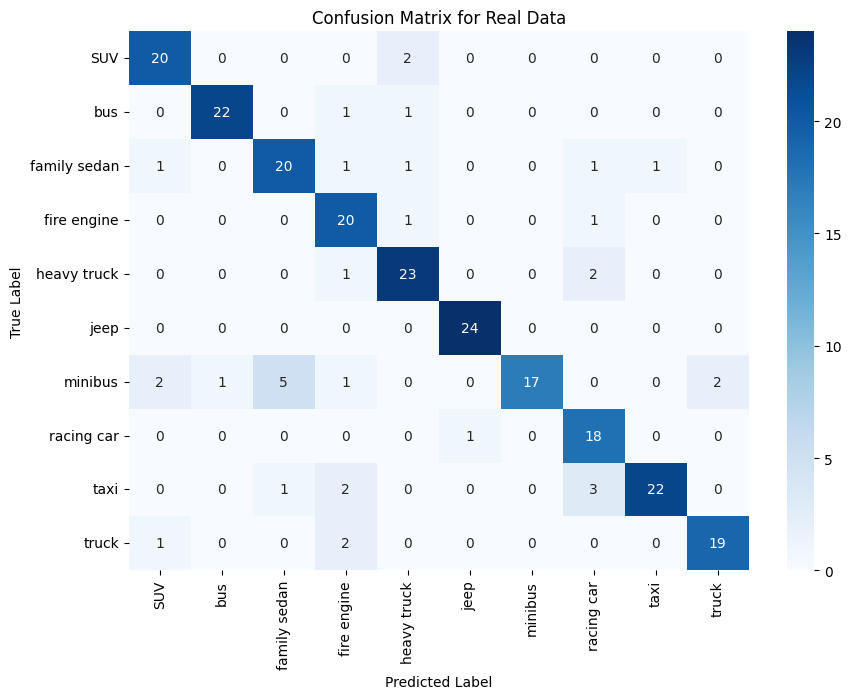

Epoch [18/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.07it/s, Loss=0.2152, Accuracy=92.95%]


Epoch [18/20] on Real Data, Loss: 0.2152, Accuracy: 92.95%
Validation Accuracy on Real Data: 76.67%
              precision    recall  f1-score   support

         SUV       0.85      0.77      0.81        22
         bus       1.00      0.96      0.98        24
family sedan       0.60      0.84      0.70        25
 fire engine       1.00      0.73      0.84        22
 heavy truck       0.94      0.62      0.74        26
        jeep       1.00      0.50      0.67        24
     minibus       0.67      0.71      0.69        28
  racing car       0.83      0.79      0.81        19
        taxi       0.76      0.89      0.82        28
       truck       0.53      0.86      0.66        22

    accuracy                           0.77       240
   macro avg       0.82      0.77      0.77       240
weighted avg       0.81      0.77      0.77       240



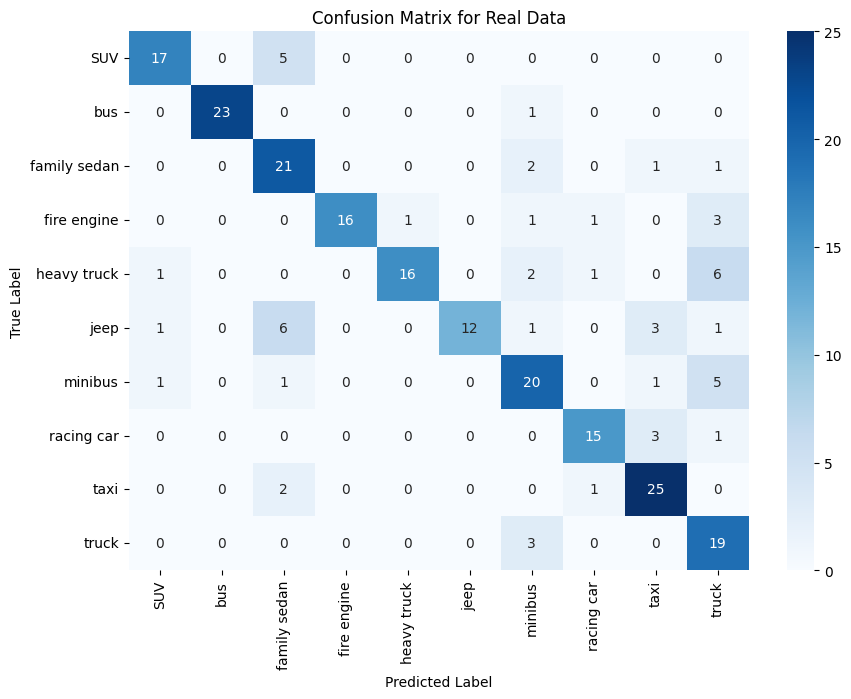

Epoch [19/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.08it/s, Loss=0.1099, Accuracy=96.07%]


Epoch [19/20] on Real Data, Loss: 0.1099, Accuracy: 96.07%
Validation Accuracy on Real Data: 82.50%
              precision    recall  f1-score   support

         SUV       0.86      0.82      0.84        22
         bus       1.00      0.88      0.93        24
family sedan       0.75      0.84      0.79        25
 fire engine       0.94      0.73      0.82        22
 heavy truck       0.84      0.81      0.82        26
        jeep       0.94      0.67      0.78        24
     minibus       0.87      0.93      0.90        28
  racing car       0.67      0.84      0.74        19
        taxi       0.82      0.82      0.82        28
       truck       0.69      0.91      0.78        22

    accuracy                           0.82       240
   macro avg       0.84      0.82      0.82       240
weighted avg       0.84      0.82      0.83       240



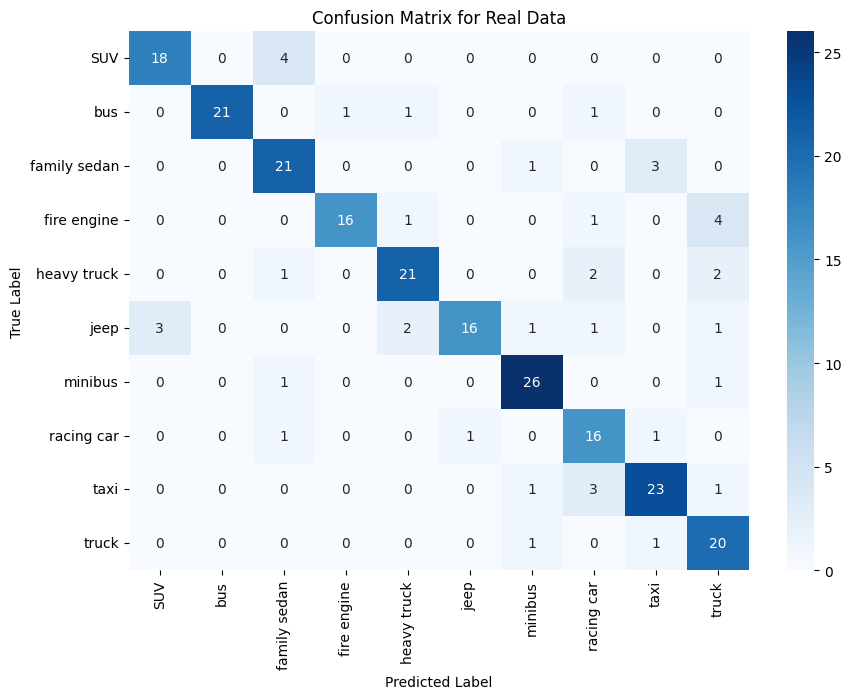

Epoch [20/20] on Real Data: 100%|██████████| 35/35 [00:32<00:00,  1.07it/s, Loss=0.0782, Accuracy=97.68%]


Epoch [20/20] on Real Data, Loss: 0.0782, Accuracy: 97.68%
Validation Accuracy on Real Data: 70.42%
              precision    recall  f1-score   support

         SUV       0.90      0.82      0.86        22
         bus       1.00      0.92      0.96        24
family sedan       0.62      0.80      0.70        25
 fire engine       1.00      0.73      0.84        22
 heavy truck       0.81      0.81      0.81        26
        jeep       1.00      0.29      0.45        24
     minibus       0.88      0.54      0.67        28
  racing car       0.31      1.00      0.47        19
        taxi       0.78      0.50      0.61        28
       truck       0.81      0.77      0.79        22

    accuracy                           0.70       240
   macro avg       0.81      0.72      0.72       240
weighted avg       0.82      0.70      0.72       240



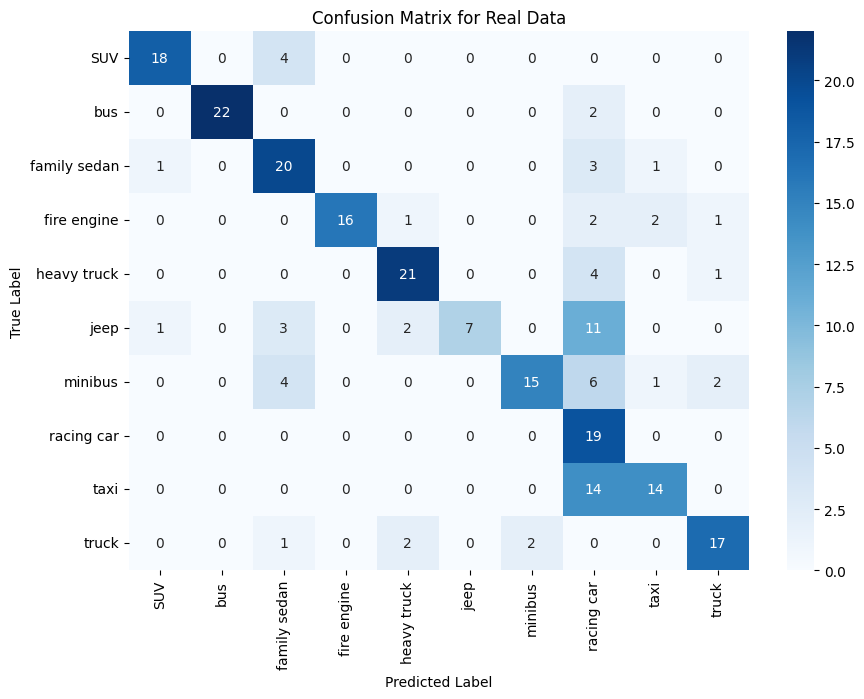

Training on Synthetic Data...


Epoch [1/20] on Synthetic Data: 100%|██████████| 94/94 [46:45<00:00, 29.85s/it, Loss=0.8223, Accuracy=71.87%]


Epoch [1/20] on Synthetic Data, Loss: 0.8223, Accuracy: 71.87%
Validation Accuracy on Synthetic Data: 29.17%
              precision    recall  f1-score   support

         SUV       0.20      0.05      0.07        22
         bus       0.00      0.00      0.00        24
family sedan       0.22      0.84      0.34        25
 fire engine       0.69      0.41      0.51        22
 heavy truck       0.35      0.73      0.47        26
        jeep       0.00      0.00      0.00        24
     minibus       0.19      0.36      0.25        28
  racing car       1.00      0.32      0.48        19
        taxi       0.57      0.14      0.23        28
       truck       0.00      0.00      0.00        22

    accuracy                           0.29       240
   macro avg       0.32      0.28      0.24       240
weighted avg       0.31      0.29      0.23       240



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


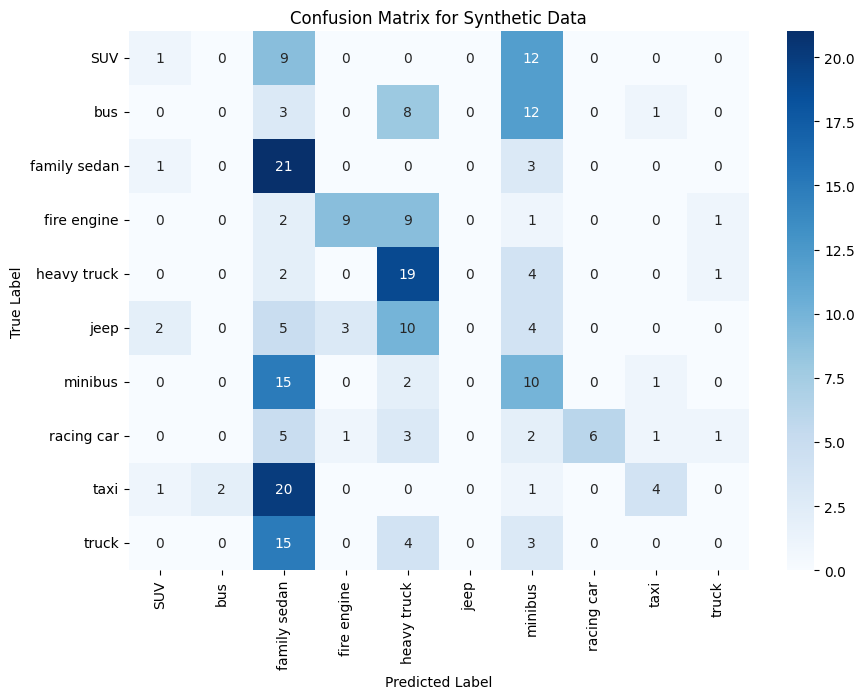

Epoch [2/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.4698, Accuracy=83.43%]


Epoch [2/20] on Synthetic Data, Loss: 0.4698, Accuracy: 83.43%
Validation Accuracy on Synthetic Data: 29.17%
              precision    recall  f1-score   support

         SUV       0.27      0.73      0.40        22
         bus       0.40      0.17      0.24        24
family sedan       0.24      0.24      0.24        25
 fire engine       0.50      0.18      0.27        22
 heavy truck       0.30      0.31      0.30        26
        jeep       1.00      0.04      0.08        24
     minibus       0.30      0.75      0.43        28
  racing car       0.75      0.32      0.44        19
        taxi       0.50      0.07      0.12        28
       truck       0.07      0.09      0.08        22

    accuracy                           0.29       240
   macro avg       0.43      0.29      0.26       240
weighted avg       0.43      0.29      0.26       240



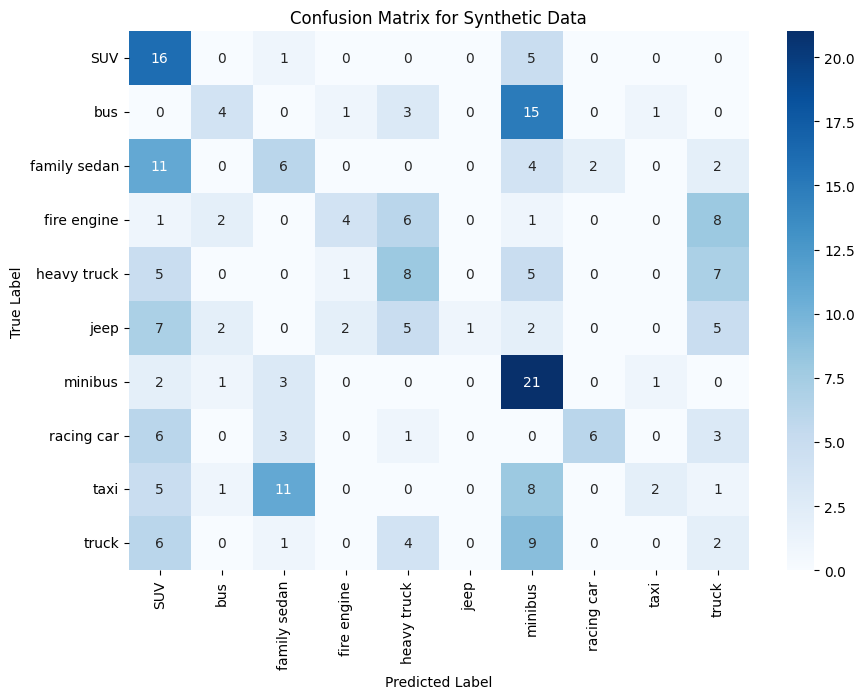

Epoch [3/20] on Synthetic Data: 100%|██████████| 94/94 [01:11<00:00,  1.31it/s, Loss=0.3856, Accuracy=86.47%]


Epoch [3/20] on Synthetic Data, Loss: 0.3856, Accuracy: 86.47%
Validation Accuracy on Synthetic Data: 37.92%
              precision    recall  f1-score   support

         SUV       0.47      0.32      0.38        22
         bus       0.44      0.29      0.35        24
family sedan       0.38      0.64      0.48        25
 fire engine       0.59      0.45      0.51        22
 heavy truck       0.29      0.77      0.43        26
        jeep       0.67      0.25      0.36        24
     minibus       0.28      0.57      0.37        28
  racing car       1.00      0.26      0.42        19
        taxi       0.67      0.14      0.24        28
       truck       0.00      0.00      0.00        22

    accuracy                           0.38       240
   macro avg       0.48      0.37      0.35       240
weighted avg       0.47      0.38      0.35       240



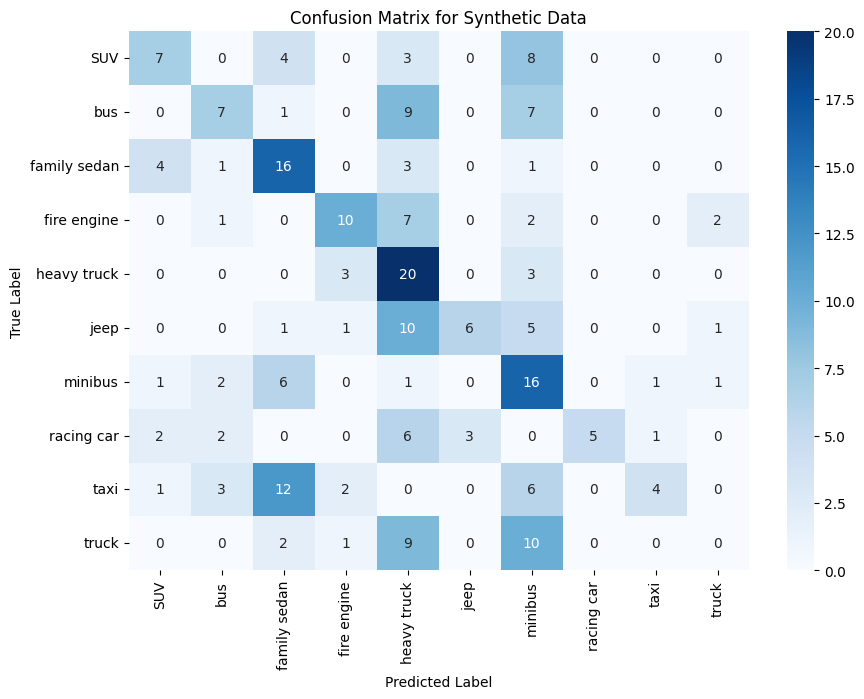

Epoch [4/20] on Synthetic Data: 100%|██████████| 94/94 [01:11<00:00,  1.31it/s, Loss=0.3202, Accuracy=89.20%]


Epoch [4/20] on Synthetic Data, Loss: 0.3202, Accuracy: 89.20%
Validation Accuracy on Synthetic Data: 41.25%
              precision    recall  f1-score   support

         SUV       0.45      0.59      0.51        22
         bus       0.64      0.67      0.65        24
family sedan       0.21      0.68      0.32        25
 fire engine       1.00      0.27      0.43        22
 heavy truck       0.64      0.69      0.67        26
        jeep       0.67      0.17      0.27        24
     minibus       0.71      0.18      0.29        28
  racing car       1.00      0.37      0.54        19
        taxi       0.67      0.29      0.40        28
       truck       0.13      0.23      0.17        22

    accuracy                           0.41       240
   macro avg       0.61      0.41      0.42       240
weighted avg       0.61      0.41      0.42       240



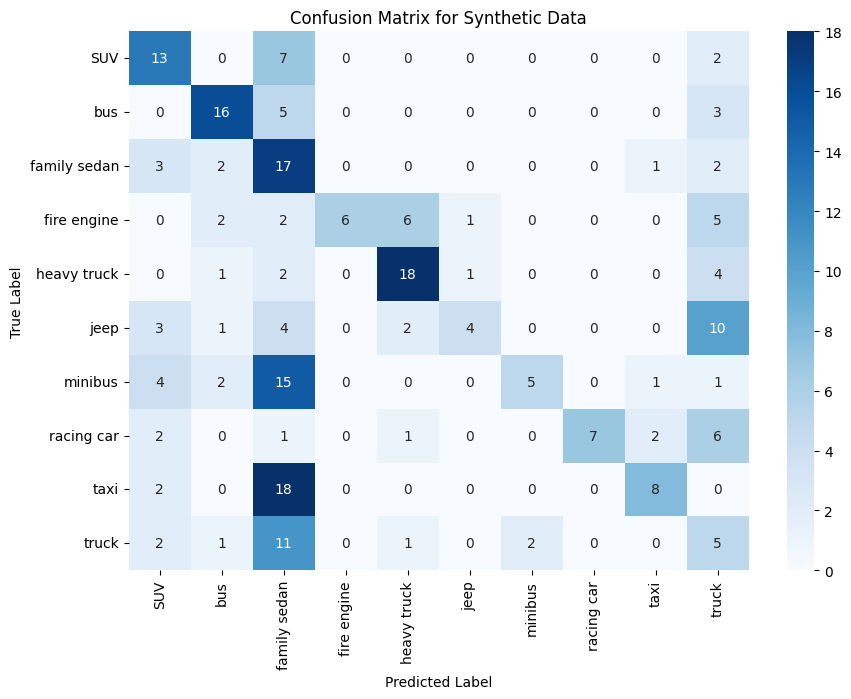

Epoch [5/20] on Synthetic Data: 100%|██████████| 94/94 [01:11<00:00,  1.31it/s, Loss=0.2857, Accuracy=90.53%]


Epoch [5/20] on Synthetic Data, Loss: 0.2857, Accuracy: 90.53%
Validation Accuracy on Synthetic Data: 35.83%
              precision    recall  f1-score   support

         SUV       0.33      0.14      0.19        22
         bus       0.35      0.67      0.46        24
family sedan       0.36      0.32      0.34        25
 fire engine       0.28      0.86      0.42        22
 heavy truck       0.31      0.38      0.34        26
        jeep       1.00      0.08      0.15        24
     minibus       0.50      0.29      0.36        28
  racing car       0.75      0.16      0.26        19
        taxi       0.53      0.61      0.57        28
       truck       0.00      0.00      0.00        22

    accuracy                           0.36       240
   macro avg       0.44      0.35      0.31       240
weighted avg       0.44      0.36      0.32       240



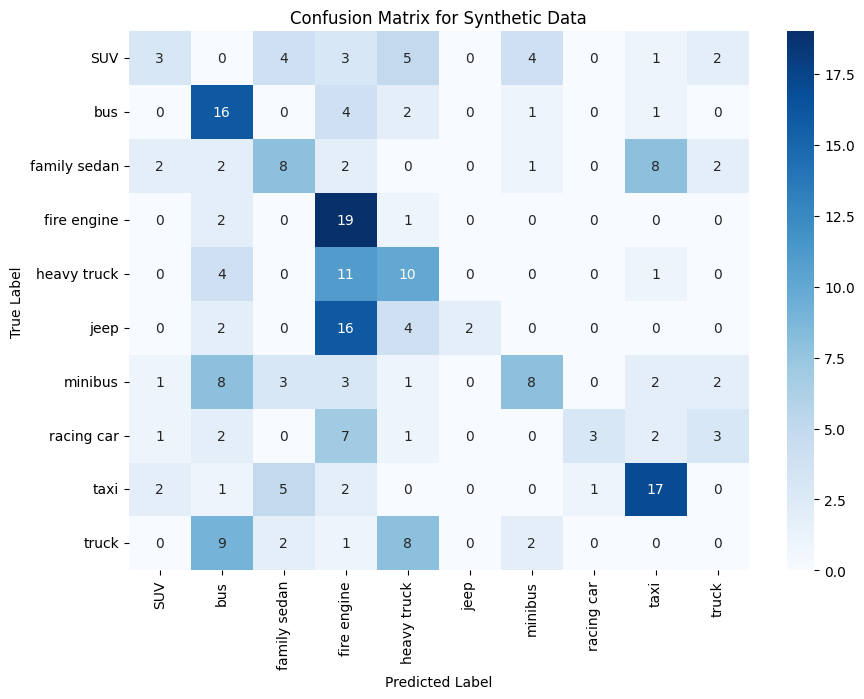

Epoch [6/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.2328, Accuracy=91.77%]


Epoch [6/20] on Synthetic Data, Loss: 0.2328, Accuracy: 91.77%
Validation Accuracy on Synthetic Data: 39.17%
              precision    recall  f1-score   support

         SUV       0.36      0.73      0.48        22
         bus       0.60      0.62      0.61        24
family sedan       0.36      0.40      0.38        25
 fire engine       1.00      0.18      0.31        22
 heavy truck       0.27      1.00      0.42        26
        jeep       0.00      0.00      0.00        24
     minibus       0.71      0.36      0.48        28
  racing car       1.00      0.37      0.54        19
        taxi       1.00      0.11      0.19        28
       truck       0.18      0.14      0.15        22

    accuracy                           0.39       240
   macro avg       0.55      0.39      0.36       240
weighted avg       0.55      0.39      0.35       240



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


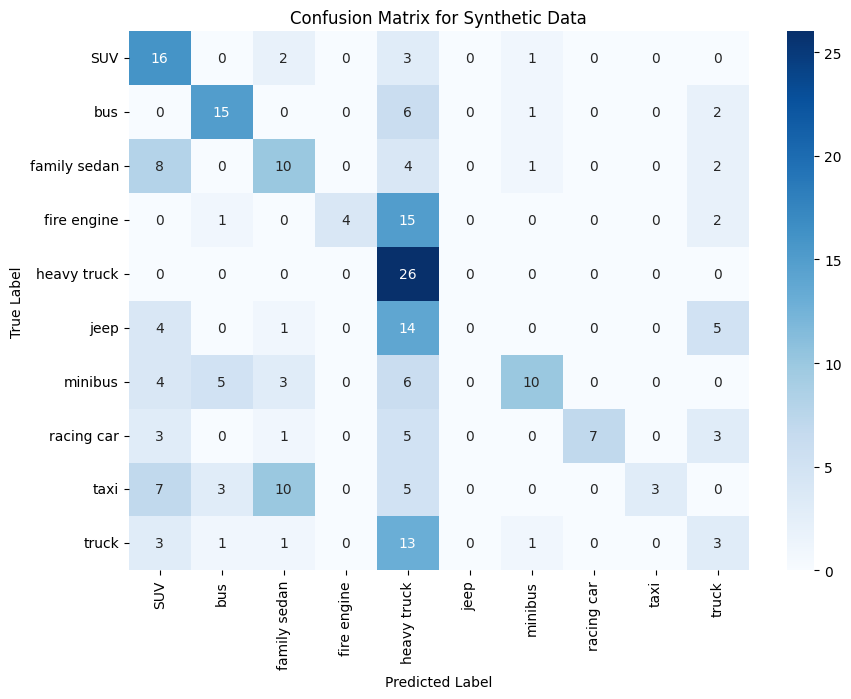

Epoch [7/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.2025, Accuracy=93.30%]


Epoch [7/20] on Synthetic Data, Loss: 0.2025, Accuracy: 93.30%
Validation Accuracy on Synthetic Data: 36.25%
              precision    recall  f1-score   support

         SUV       0.43      0.55      0.48        22
         bus       0.29      0.17      0.21        24
family sedan       0.26      0.88      0.40        25
 fire engine       1.00      0.18      0.31        22
 heavy truck       0.40      0.88      0.55        26
        jeep       0.69      0.38      0.49        24
     minibus       0.36      0.29      0.32        28
  racing car       1.00      0.16      0.27        19
        taxi       0.20      0.07      0.11        28
       truck       0.00      0.00      0.00        22

    accuracy                           0.36       240
   macro avg       0.46      0.35      0.31       240
weighted avg       0.44      0.36      0.32       240



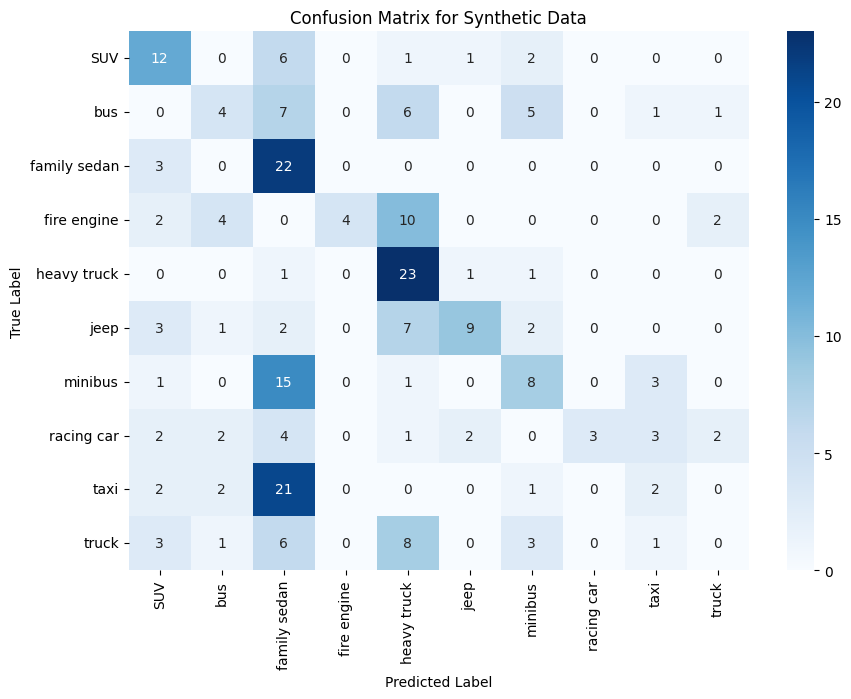

Epoch [8/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.1787, Accuracy=93.57%]


Epoch [8/20] on Synthetic Data, Loss: 0.1787, Accuracy: 93.57%
Validation Accuracy on Synthetic Data: 35.00%
              precision    recall  f1-score   support

         SUV       0.50      0.14      0.21        22
         bus       0.92      0.50      0.65        24
family sedan       0.23      0.92      0.37        25
 fire engine       1.00      0.14      0.24        22
 heavy truck       0.33      0.62      0.43        26
        jeep       0.67      0.08      0.15        24
     minibus       0.22      0.29      0.25        28
  racing car       0.88      0.74      0.80        19
        taxi       1.00      0.07      0.13        28
       truck       0.08      0.05      0.06        22

    accuracy                           0.35       240
   macro avg       0.58      0.35      0.33       240
weighted avg       0.58      0.35      0.32       240



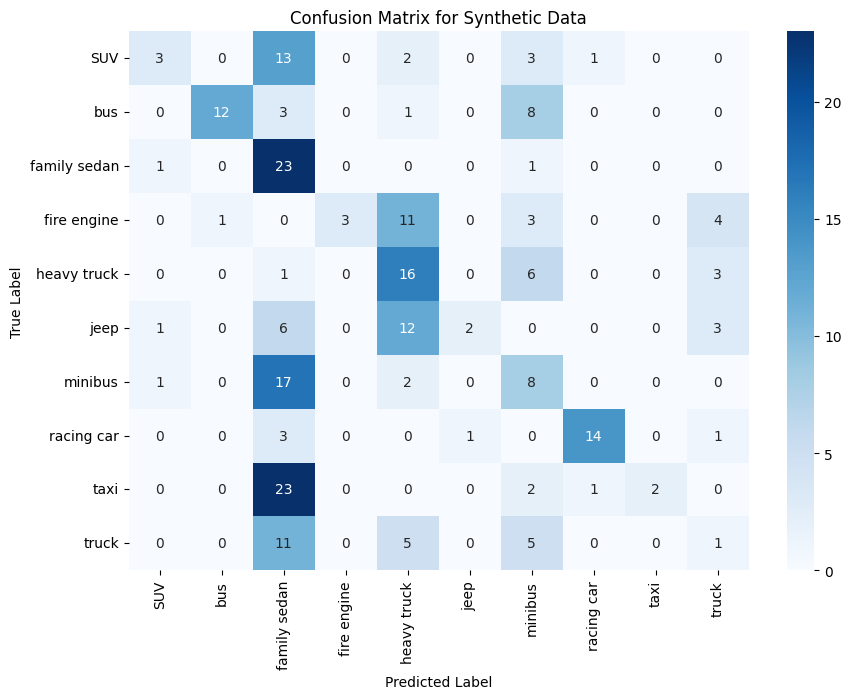

Epoch [9/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.1409, Accuracy=95.03%]


Epoch [9/20] on Synthetic Data, Loss: 0.1409, Accuracy: 95.03%
Validation Accuracy on Synthetic Data: 35.42%
              precision    recall  f1-score   support

         SUV       0.56      0.23      0.32        22
         bus       0.35      0.46      0.40        24
family sedan       0.22      0.56      0.31        25
 fire engine       0.86      0.27      0.41        22
 heavy truck       0.36      0.62      0.46        26
        jeep       1.00      0.25      0.40        24
     minibus       0.33      0.21      0.26        28
  racing car       0.48      0.74      0.58        19
        taxi       0.58      0.25      0.35        28
       truck       0.00      0.00      0.00        22

    accuracy                           0.35       240
   macro avg       0.47      0.36      0.35       240
weighted avg       0.47      0.35      0.35       240



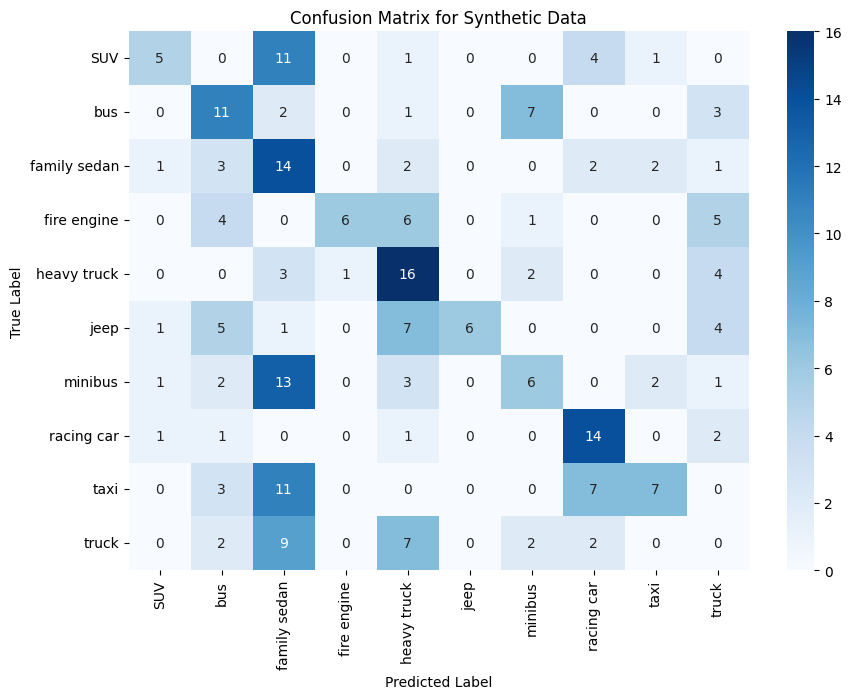

Epoch [10/20] on Synthetic Data: 100%|██████████| 94/94 [01:14<00:00,  1.26it/s, Loss=0.1484, Accuracy=94.80%]


Epoch [10/20] on Synthetic Data, Loss: 0.1484, Accuracy: 94.80%
Validation Accuracy on Synthetic Data: 35.42%
              precision    recall  f1-score   support

         SUV       0.28      0.95      0.44        22
         bus       0.75      0.12      0.21        24
family sedan       0.31      0.40      0.35        25
 fire engine       0.00      0.00      0.00        22
 heavy truck       0.38      0.69      0.49        26
        jeep       1.00      0.42      0.59        24
     minibus       0.18      0.11      0.13        28
  racing car       0.86      0.63      0.73        19
        taxi       0.50      0.18      0.26        28
       truck       0.10      0.14      0.11        22

    accuracy                           0.35       240
   macro avg       0.44      0.36      0.33       240
weighted avg       0.43      0.35      0.32       240



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


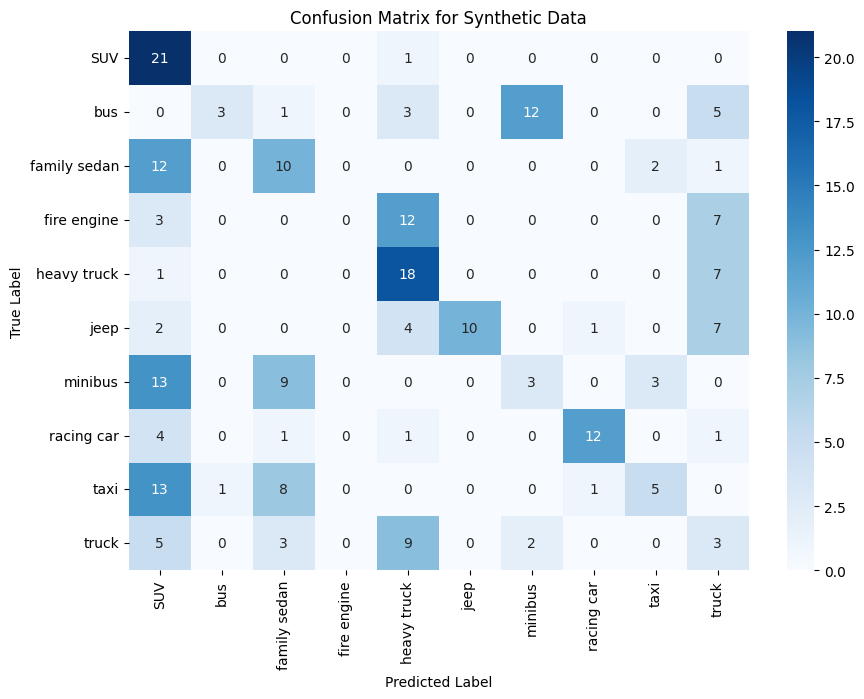

Epoch [11/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.1337, Accuracy=95.43%]


Epoch [11/20] on Synthetic Data, Loss: 0.1337, Accuracy: 95.43%
Validation Accuracy on Synthetic Data: 43.33%
              precision    recall  f1-score   support

         SUV       0.83      0.23      0.36        22
         bus       0.61      0.71      0.65        24
family sedan       0.30      0.84      0.44        25
 fire engine       0.80      0.36      0.50        22
 heavy truck       0.38      0.92      0.53        26
        jeep       1.00      0.12      0.22        24
     minibus       0.31      0.14      0.20        28
  racing car       0.73      0.58      0.65        19
        taxi       0.67      0.36      0.47        28
       truck       0.06      0.05      0.05        22

    accuracy                           0.43       240
   macro avg       0.57      0.43      0.41       240
weighted avg       0.56      0.43      0.40       240



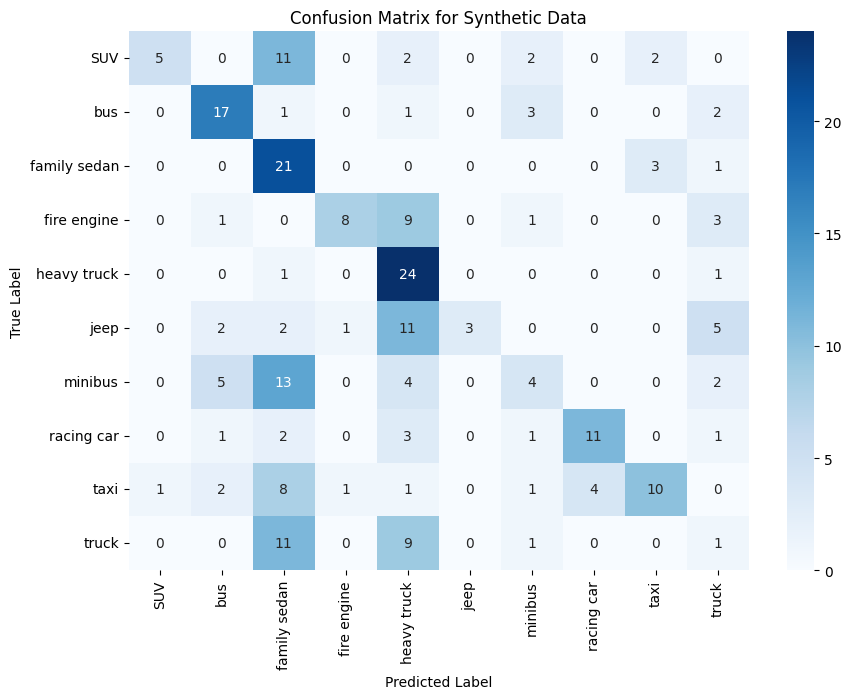

Epoch [12/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.1345, Accuracy=95.23%]


Epoch [12/20] on Synthetic Data, Loss: 0.1345, Accuracy: 95.23%
Validation Accuracy on Synthetic Data: 51.25%
              precision    recall  f1-score   support

         SUV       0.46      0.73      0.56        22
         bus       0.72      0.54      0.62        24
family sedan       0.39      0.80      0.53        25
 fire engine       0.67      0.73      0.70        22
 heavy truck       0.72      0.50      0.59        26
        jeep       1.00      0.33      0.50        24
     minibus       0.31      0.54      0.39        28
  racing car       0.71      0.53      0.61        19
        taxi       0.61      0.39      0.48        28
       truck       0.17      0.05      0.07        22

    accuracy                           0.51       240
   macro avg       0.58      0.51      0.50       240
weighted avg       0.57      0.51      0.50       240



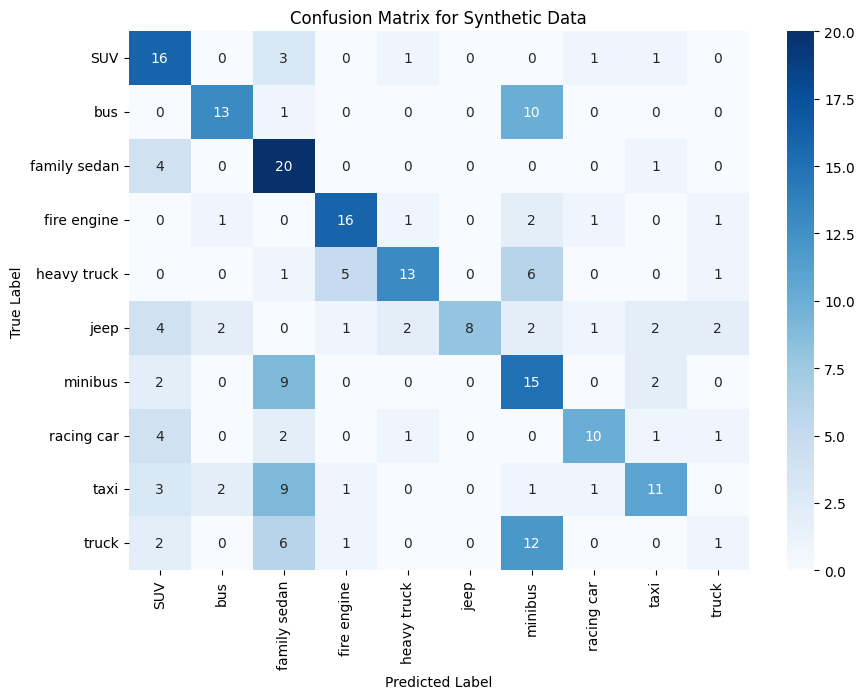

Epoch [13/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.29it/s, Loss=0.1252, Accuracy=95.73%]


Epoch [13/20] on Synthetic Data, Loss: 0.1252, Accuracy: 95.73%
Validation Accuracy on Synthetic Data: 26.25%
              precision    recall  f1-score   support

         SUV       0.20      0.05      0.07        22
         bus       0.53      0.42      0.47        24
family sedan       0.60      0.12      0.20        25
 fire engine       0.00      0.00      0.00        22
 heavy truck       1.00      0.15      0.27        26
        jeep       1.00      0.04      0.08        24
     minibus       0.21      0.86      0.33        28
  racing car       0.22      0.84      0.34        19
        taxi       1.00      0.11      0.19        28
       truck       0.08      0.05      0.06        22

    accuracy                           0.26       240
   macro avg       0.48      0.26      0.20       240
weighted avg       0.51      0.26      0.20       240



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


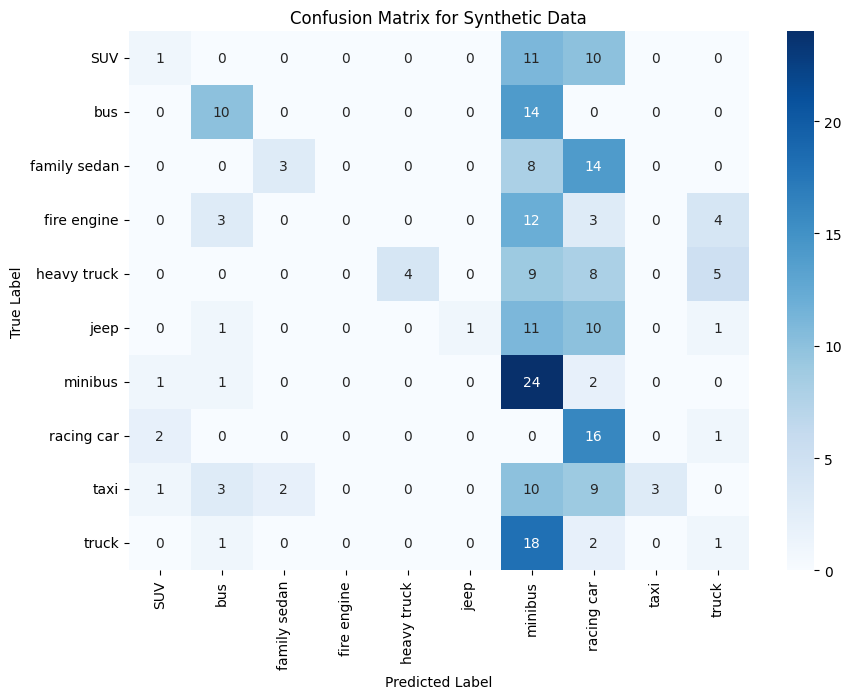

Epoch [14/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.1342, Accuracy=95.80%]


Epoch [14/20] on Synthetic Data, Loss: 0.1342, Accuracy: 95.80%
Validation Accuracy on Synthetic Data: 47.50%
              precision    recall  f1-score   support

         SUV       1.00      0.18      0.31        22
         bus       0.38      0.75      0.50        24
family sedan       0.50      0.60      0.55        25
 fire engine       1.00      0.18      0.31        22
 heavy truck       0.42      0.88      0.57        26
        jeep       0.89      0.33      0.48        24
     minibus       0.36      0.57      0.44        28
  racing car       1.00      0.42      0.59        19
        taxi       0.62      0.54      0.58        28
       truck       0.21      0.14      0.17        22

    accuracy                           0.47       240
   macro avg       0.64      0.46      0.45       240
weighted avg       0.62      0.47      0.45       240



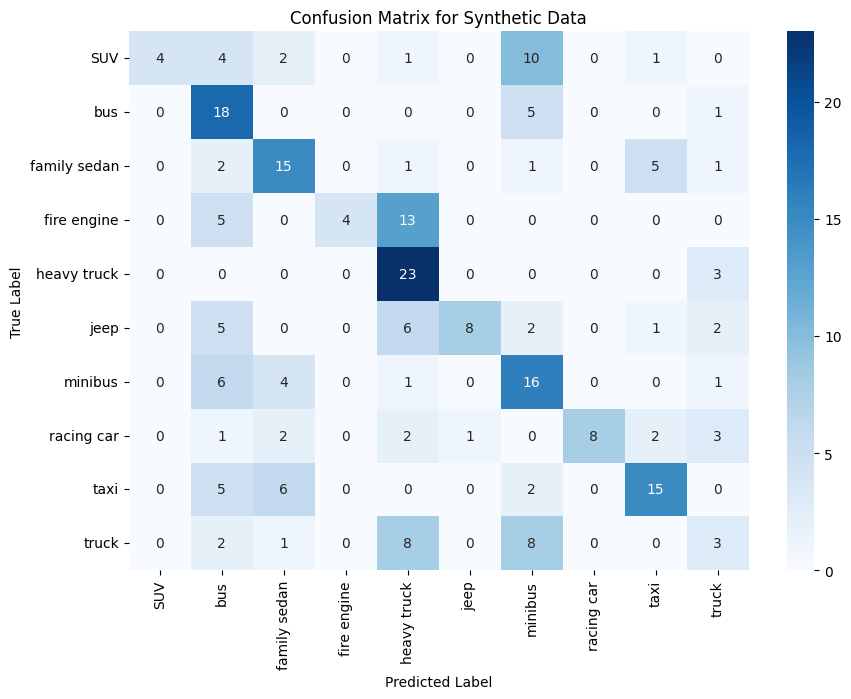

Epoch [15/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.0819, Accuracy=97.40%]


Epoch [15/20] on Synthetic Data, Loss: 0.0819, Accuracy: 97.40%
Validation Accuracy on Synthetic Data: 48.33%
              precision    recall  f1-score   support

         SUV       0.56      0.45      0.50        22
         bus       0.73      0.67      0.70        24
family sedan       0.22      0.56      0.31        25
 fire engine       0.75      0.82      0.78        22
 heavy truck       0.60      0.81      0.69        26
        jeep       1.00      0.21      0.34        24
     minibus       0.40      0.29      0.33        28
  racing car       0.87      0.68      0.76        19
        taxi       0.48      0.39      0.43        28
       truck       0.00      0.00      0.00        22

    accuracy                           0.48       240
   macro avg       0.56      0.49      0.49       240
weighted avg       0.55      0.48      0.48       240



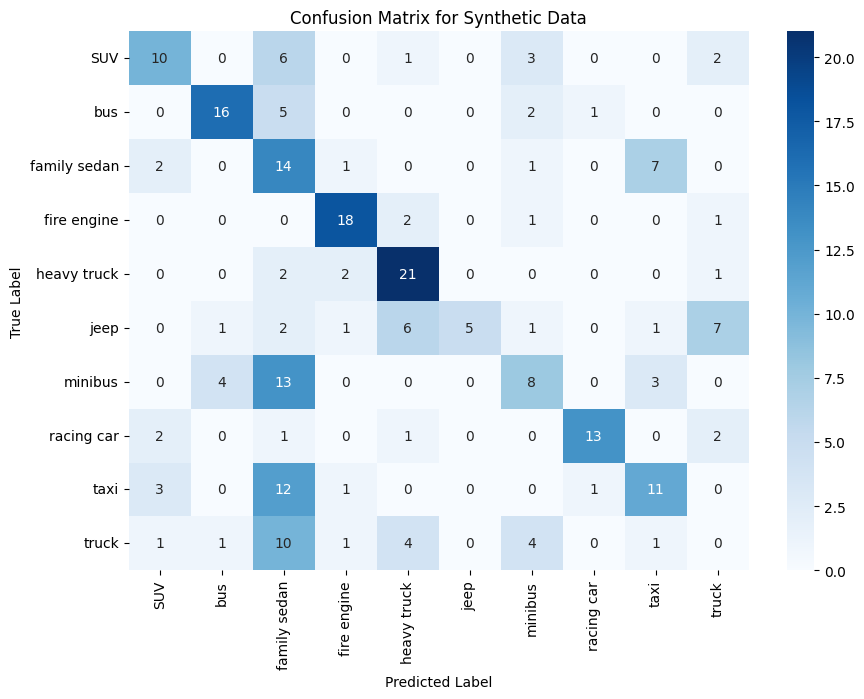

Epoch [16/20] on Synthetic Data: 100%|██████████| 94/94 [01:11<00:00,  1.31it/s, Loss=0.0634, Accuracy=97.77%]


Epoch [16/20] on Synthetic Data, Loss: 0.0634, Accuracy: 97.77%
Validation Accuracy on Synthetic Data: 43.75%
              precision    recall  f1-score   support

         SUV       0.64      0.41      0.50        22
         bus       0.41      0.50      0.45        24
family sedan       0.41      0.68      0.52        25
 fire engine       0.50      0.05      0.08        22
 heavy truck       0.41      0.88      0.56        26
        jeep       0.88      0.29      0.44        24
     minibus       0.32      0.54      0.40        28
  racing car       0.85      0.58      0.69        19
        taxi       0.70      0.25      0.37        28
       truck       0.15      0.14      0.14        22

    accuracy                           0.44       240
   macro avg       0.53      0.43      0.41       240
weighted avg       0.52      0.44      0.41       240



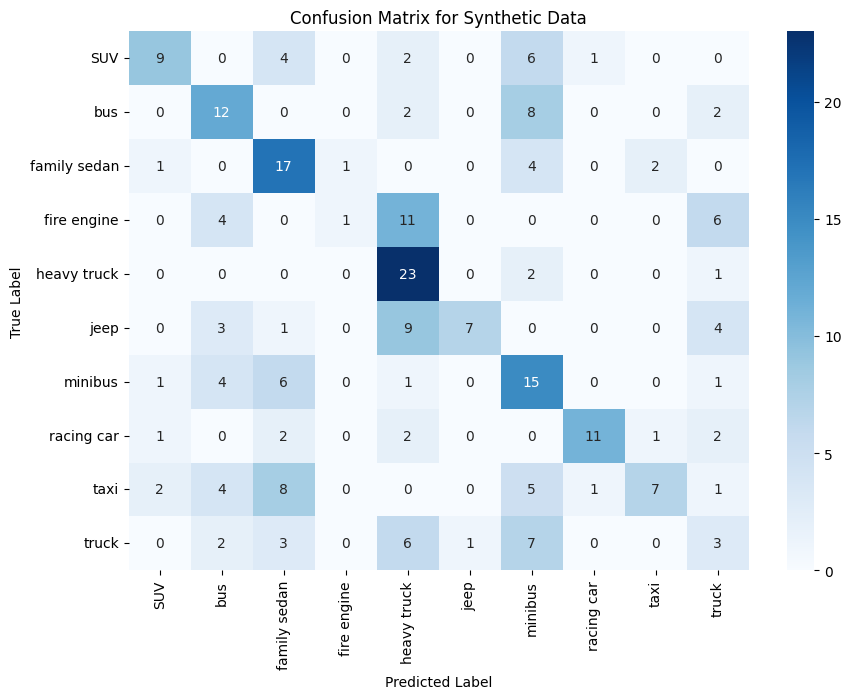

Epoch [17/20] on Synthetic Data: 100%|██████████| 94/94 [01:11<00:00,  1.31it/s, Loss=0.1023, Accuracy=96.60%]


Epoch [17/20] on Synthetic Data, Loss: 0.1023, Accuracy: 96.60%
Validation Accuracy on Synthetic Data: 47.92%
              precision    recall  f1-score   support

         SUV       0.59      0.73      0.65        22
         bus       0.43      0.50      0.46        24
family sedan       0.31      0.40      0.35        25
 fire engine       0.42      0.86      0.57        22
 heavy truck       0.56      0.35      0.43        26
        jeep       0.68      0.62      0.65        24
     minibus       0.42      0.36      0.38        28
  racing car       0.78      0.37      0.50        19
        taxi       0.80      0.43      0.56        28
       truck       0.23      0.23      0.23        22

    accuracy                           0.48       240
   macro avg       0.52      0.48      0.48       240
weighted avg       0.52      0.48      0.48       240



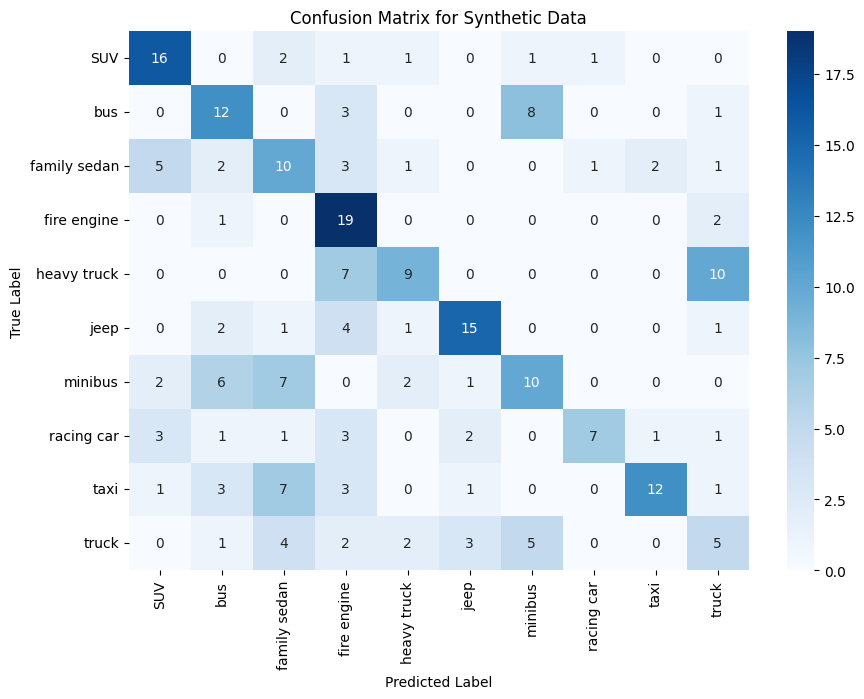

Epoch [18/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.31it/s, Loss=0.0991, Accuracy=96.77%]


Epoch [18/20] on Synthetic Data, Loss: 0.0991, Accuracy: 96.77%
Validation Accuracy on Synthetic Data: 33.75%
              precision    recall  f1-score   support

         SUV       0.41      0.59      0.48        22
         bus       0.35      0.25      0.29        24
family sedan       0.30      0.64      0.41        25
 fire engine       0.71      0.23      0.34        22
 heavy truck       0.32      0.58      0.41        26
        jeep       0.00      0.00      0.00        24
     minibus       0.40      0.29      0.33        28
  racing car       1.00      0.16      0.27        19
        taxi       0.44      0.29      0.35        28
       truck       0.17      0.32      0.22        22

    accuracy                           0.34       240
   macro avg       0.41      0.33      0.31       240
weighted avg       0.40      0.34      0.31       240



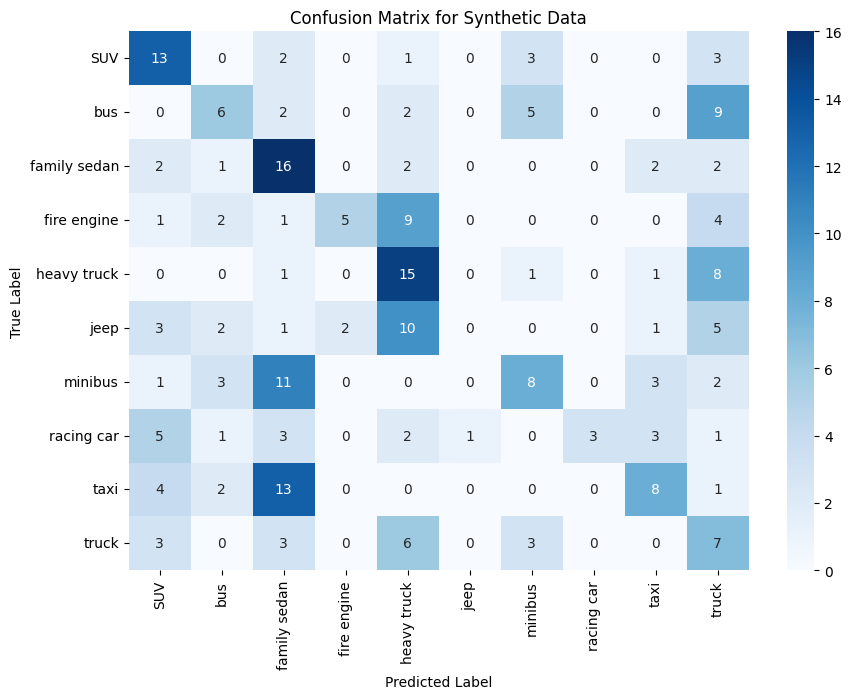

Epoch [19/20] on Synthetic Data: 100%|██████████| 94/94 [01:12<00:00,  1.30it/s, Loss=0.1340, Accuracy=95.13%]


Epoch [19/20] on Synthetic Data, Loss: 0.1340, Accuracy: 95.13%
Validation Accuracy on Synthetic Data: 40.83%
              precision    recall  f1-score   support

         SUV       0.58      0.50      0.54        22
         bus       0.53      0.42      0.47        24
family sedan       0.23      0.72      0.35        25
 fire engine       0.40      0.86      0.55        22
 heavy truck       0.54      0.58      0.56        26
        jeep       0.52      0.46      0.49        24
     minibus       0.60      0.32      0.42        28
  racing car       0.71      0.26      0.38        19
        taxi       0.00      0.00      0.00        28
       truck       0.00      0.00      0.00        22

    accuracy                           0.41       240
   macro avg       0.41      0.41      0.37       240
weighted avg       0.40      0.41      0.37       240



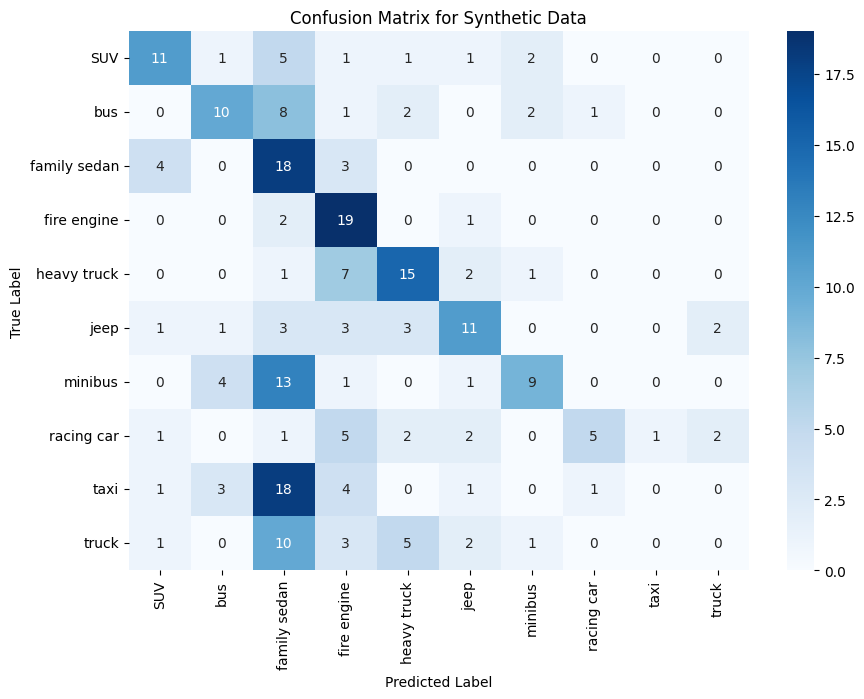

Epoch [20/20] on Synthetic Data: 100%|██████████| 94/94 [01:11<00:00,  1.31it/s, Loss=0.1415, Accuracy=95.50%]


Epoch [20/20] on Synthetic Data, Loss: 0.1415, Accuracy: 95.50%
Validation Accuracy on Synthetic Data: 34.17%
              precision    recall  f1-score   support

         SUV       0.46      0.27      0.34        22
         bus       0.50      0.92      0.65        24
family sedan       0.24      0.80      0.37        25
 fire engine       1.00      0.05      0.09        22
 heavy truck       0.36      0.85      0.51        26
        jeep       0.45      0.21      0.29        24
     minibus       0.20      0.04      0.06        28
  racing car       0.75      0.16      0.26        19
        taxi       0.50      0.04      0.07        28
       truck       0.07      0.05      0.05        22

    accuracy                           0.34       240
   macro avg       0.45      0.34      0.27       240
weighted avg       0.44      0.34      0.27       240



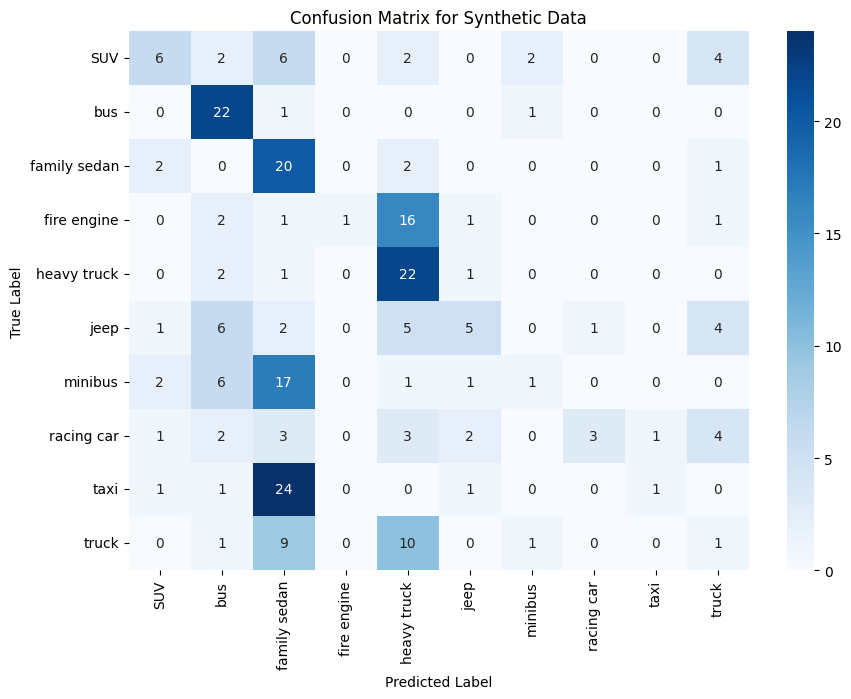

Training on Hybrid Data...


Epoch [1/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.8894, Accuracy=69.15%]


Epoch [1/20] on Hybrid Data, Loss: 0.8894, Accuracy: 69.15%
Validation Accuracy on Hybrid Data: 43.33%
              precision    recall  f1-score   support

         SUV       1.00      0.14      0.24        22
         bus       0.82      0.96      0.88        24
family sedan       0.21      0.96      0.35        25
 fire engine       0.76      0.73      0.74        22
 heavy truck       1.00      0.27      0.42        26
        jeep       0.67      0.08      0.15        24
     minibus       0.33      0.50      0.40        28
  racing car       1.00      0.37      0.54        19
        taxi       0.50      0.07      0.12        28
       truck       0.55      0.27      0.36        22

    accuracy                           0.43       240
   macro avg       0.68      0.43      0.42       240
weighted avg       0.67      0.43      0.41       240



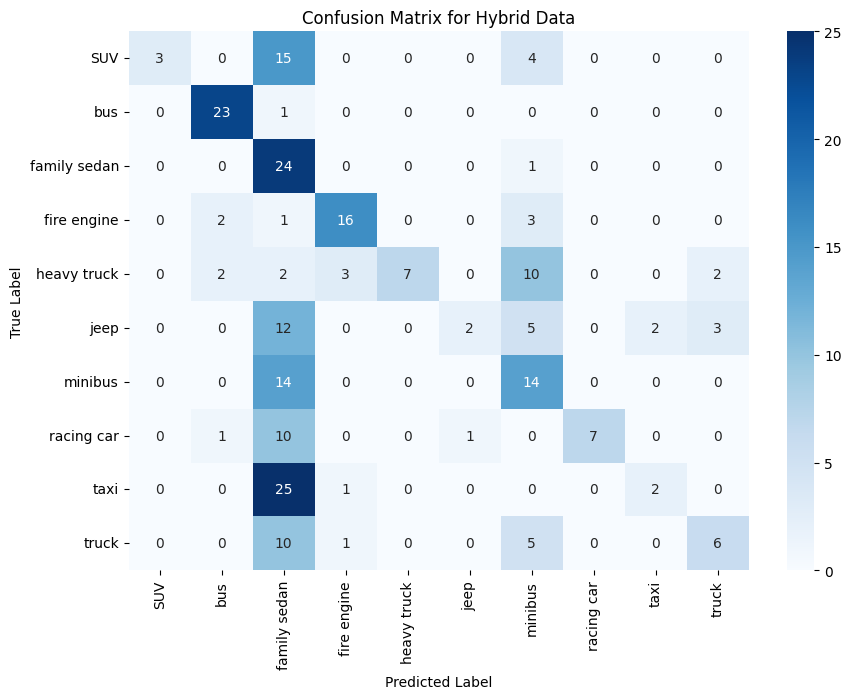

Epoch [2/20] on Hybrid Data: 100%|██████████| 129/129 [01:45<00:00,  1.22it/s, Loss=0.5383, Accuracy=81.63%]


Epoch [2/20] on Hybrid Data, Loss: 0.5383, Accuracy: 81.63%
Validation Accuracy on Hybrid Data: 61.67%
              precision    recall  f1-score   support

         SUV       0.60      0.95      0.74        22
         bus       0.94      0.67      0.78        24
family sedan       0.57      0.16      0.25        25
 fire engine       0.80      0.73      0.76        22
 heavy truck       0.86      0.69      0.77        26
        jeep       0.39      0.92      0.54        24
     minibus       0.83      0.36      0.50        28
  racing car       0.94      0.79      0.86        19
        taxi       0.47      0.82      0.60        28
       truck       0.50      0.14      0.21        22

    accuracy                           0.62       240
   macro avg       0.69      0.62      0.60       240
weighted avg       0.69      0.62      0.59       240



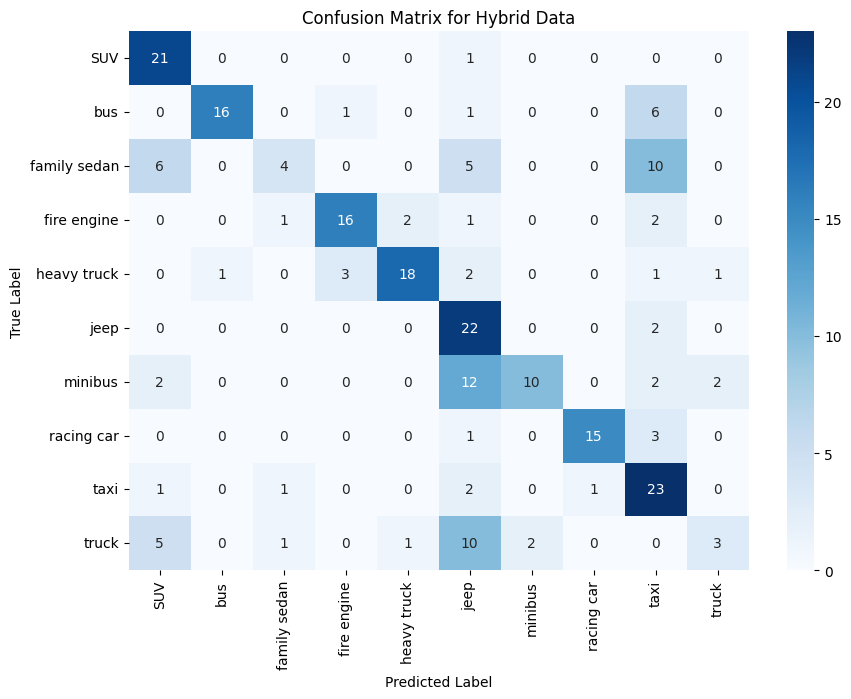

Epoch [3/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.4205, Accuracy=85.53%]


Epoch [3/20] on Hybrid Data, Loss: 0.4205, Accuracy: 85.53%
Validation Accuracy on Hybrid Data: 58.75%
              precision    recall  f1-score   support

         SUV       0.93      0.64      0.76        22
         bus       0.31      1.00      0.47        24
family sedan       0.67      0.72      0.69        25
 fire engine       0.76      0.86      0.81        22
 heavy truck       0.59      0.62      0.60        26
        jeep       1.00      0.33      0.50        24
     minibus       0.93      0.46      0.62        28
  racing car       1.00      0.32      0.48        19
        taxi       0.74      0.50      0.60        28
       truck       0.43      0.41      0.42        22

    accuracy                           0.59       240
   macro avg       0.74      0.59      0.59       240
weighted avg       0.73      0.59      0.60       240



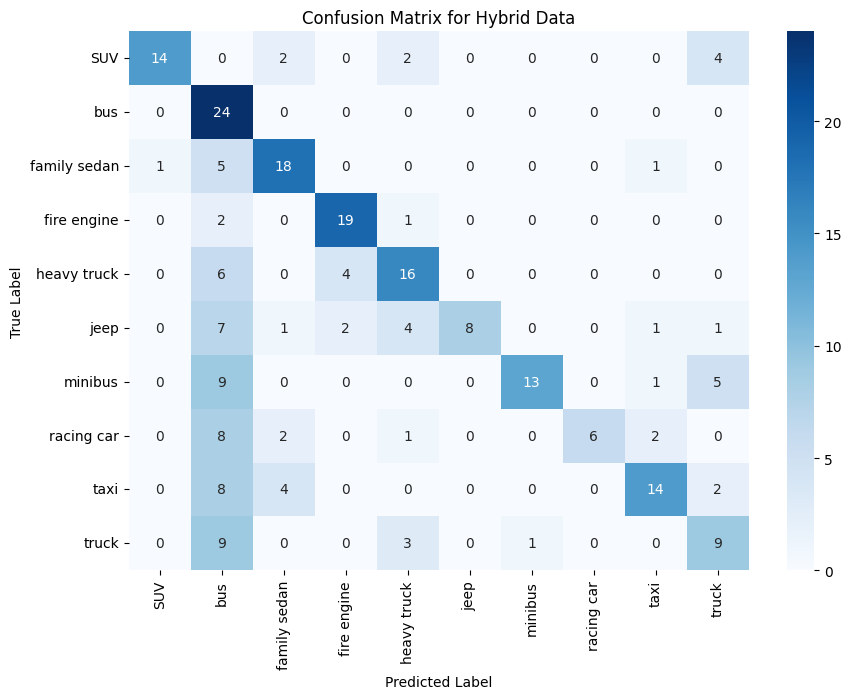

Epoch [4/20] on Hybrid Data: 100%|██████████| 129/129 [01:44<00:00,  1.23it/s, Loss=0.3527, Accuracy=87.67%]


Epoch [4/20] on Hybrid Data, Loss: 0.3527, Accuracy: 87.67%
Validation Accuracy on Hybrid Data: 72.92%
              precision    recall  f1-score   support

         SUV       0.79      0.68      0.73        22
         bus       0.74      0.96      0.84        24
family sedan       0.53      0.84      0.65        25
 fire engine       1.00      0.64      0.78        22
 heavy truck       0.79      0.88      0.84        26
        jeep       1.00      0.58      0.74        24
     minibus       0.59      0.82      0.69        28
  racing car       1.00      0.63      0.77        19
        taxi       0.73      0.57      0.64        28
       truck       0.70      0.64      0.67        22

    accuracy                           0.73       240
   macro avg       0.79      0.72      0.73       240
weighted avg       0.78      0.73      0.73       240



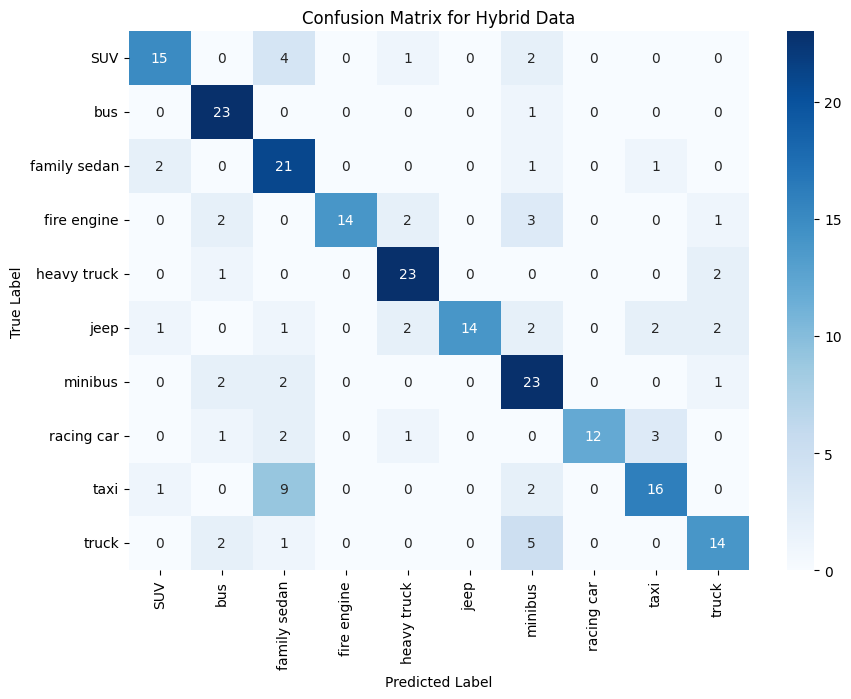

Epoch [5/20] on Hybrid Data: 100%|██████████| 129/129 [01:45<00:00,  1.22it/s, Loss=0.3021, Accuracy=89.56%]


Epoch [5/20] on Hybrid Data, Loss: 0.3021, Accuracy: 89.56%
Validation Accuracy on Hybrid Data: 70.42%
              precision    recall  f1-score   support

         SUV       0.61      0.91      0.73        22
         bus       0.84      0.88      0.86        24
family sedan       0.65      0.52      0.58        25
 fire engine       0.94      0.73      0.82        22
 heavy truck       0.91      0.81      0.86        26
        jeep       0.43      1.00      0.60        24
     minibus       0.88      0.54      0.67        28
  racing car       1.00      0.68      0.81        19
        taxi       1.00      0.21      0.35        28
       truck       0.67      0.91      0.77        22

    accuracy                           0.70       240
   macro avg       0.79      0.72      0.70       240
weighted avg       0.80      0.70      0.69       240



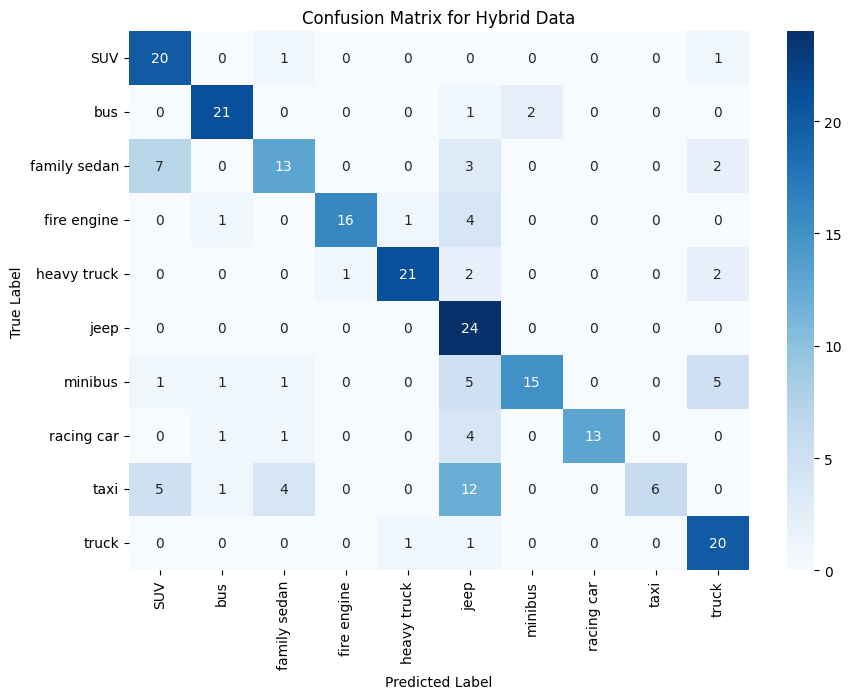

Epoch [6/20] on Hybrid Data: 100%|██████████| 129/129 [01:45<00:00,  1.23it/s, Loss=0.2188, Accuracy=92.60%]


Epoch [6/20] on Hybrid Data, Loss: 0.2188, Accuracy: 92.60%
Validation Accuracy on Hybrid Data: 79.17%
              precision    recall  f1-score   support

         SUV       0.77      0.91      0.83        22
         bus       0.95      0.88      0.91        24
family sedan       0.62      0.92      0.74        25
 fire engine       0.85      0.77      0.81        22
 heavy truck       0.95      0.77      0.85        26
        jeep       0.89      0.67      0.76        24
     minibus       0.76      0.79      0.77        28
  racing car       0.63      0.89      0.74        19
        taxi       0.88      0.75      0.81        28
       truck       0.81      0.59      0.68        22

    accuracy                           0.79       240
   macro avg       0.81      0.79      0.79       240
weighted avg       0.82      0.79      0.79       240



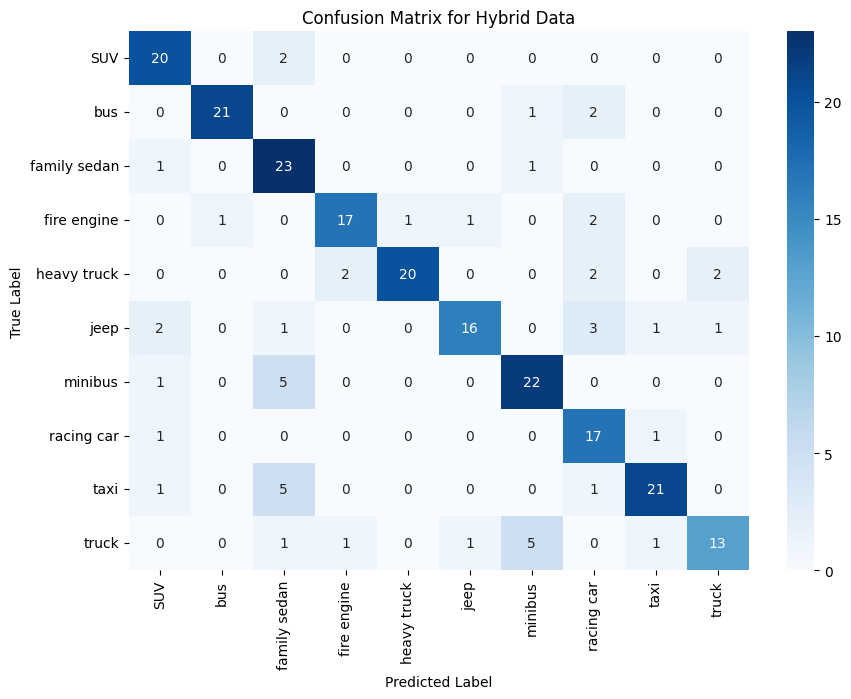

Epoch [7/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.2337, Accuracy=92.43%]


Epoch [7/20] on Hybrid Data, Loss: 0.2337, Accuracy: 92.43%
Validation Accuracy on Hybrid Data: 70.00%
              precision    recall  f1-score   support

         SUV       0.89      0.77      0.83        22
         bus       0.70      0.96      0.81        24
family sedan       0.68      0.84      0.75        25
 fire engine       1.00      0.59      0.74        22
 heavy truck       0.95      0.69      0.80        26
        jeep       1.00      0.42      0.59        24
     minibus       0.92      0.43      0.59        28
  racing car       0.53      0.95      0.68        19
        taxi       0.59      0.68      0.63        28
       truck       0.47      0.77      0.59        22

    accuracy                           0.70       240
   macro avg       0.77      0.71      0.70       240
weighted avg       0.78      0.70      0.70       240



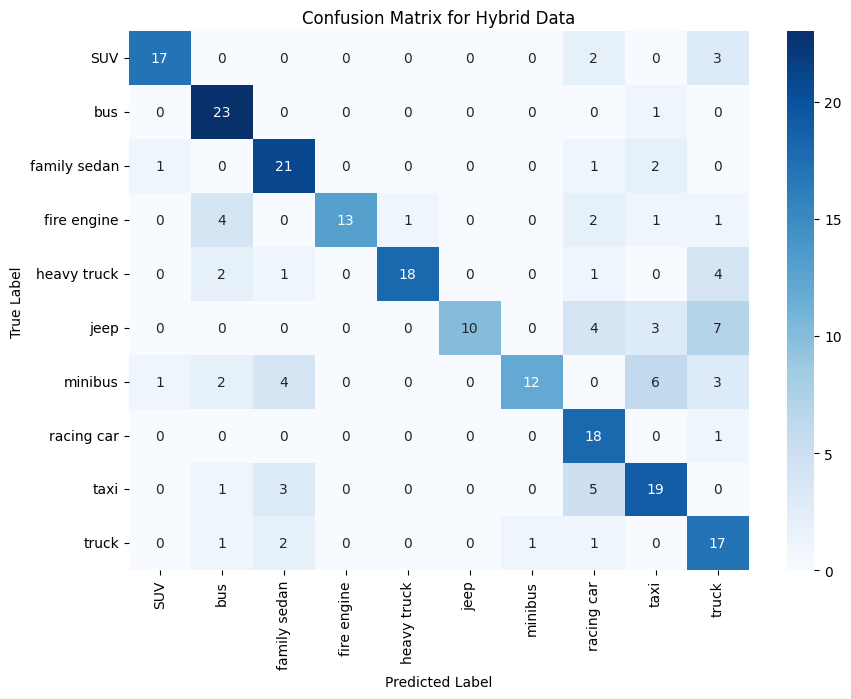

Epoch [8/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.1913, Accuracy=93.62%]


Epoch [8/20] on Hybrid Data, Loss: 0.1913, Accuracy: 93.62%
Validation Accuracy on Hybrid Data: 82.92%
              precision    recall  f1-score   support

         SUV       0.67      1.00      0.80        22
         bus       0.92      1.00      0.96        24
family sedan       0.73      0.76      0.75        25
 fire engine       0.91      0.91      0.91        22
 heavy truck       1.00      0.77      0.87        26
        jeep       0.91      0.88      0.89        24
     minibus       0.71      0.71      0.71        28
  racing car       0.93      0.74      0.82        19
        taxi       0.83      0.89      0.86        28
       truck       0.82      0.64      0.72        22

    accuracy                           0.83       240
   macro avg       0.84      0.83      0.83       240
weighted avg       0.84      0.83      0.83       240



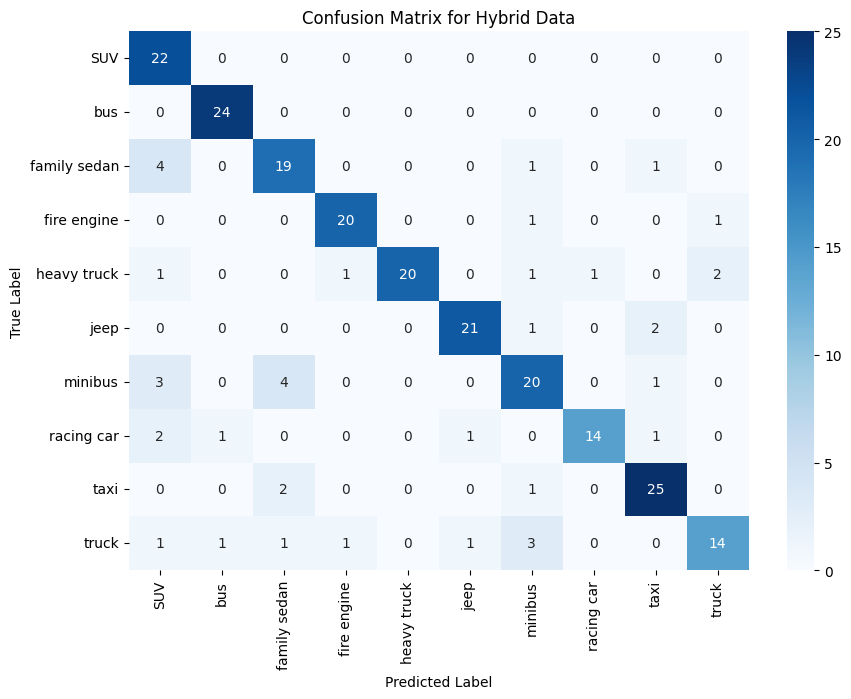

Epoch [9/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.1604, Accuracy=94.56%]


Epoch [9/20] on Hybrid Data, Loss: 0.1604, Accuracy: 94.56%
Validation Accuracy on Hybrid Data: 78.75%
              precision    recall  f1-score   support

         SUV       0.83      0.91      0.87        22
         bus       1.00      0.96      0.98        24
family sedan       0.50      0.84      0.63        25
 fire engine       0.93      0.64      0.76        22
 heavy truck       0.79      0.85      0.81        26
        jeep       0.79      0.96      0.87        24
     minibus       0.86      0.43      0.57        28
  racing car       1.00      0.89      0.94        19
        taxi       0.90      0.68      0.78        28
       truck       0.67      0.82      0.73        22

    accuracy                           0.79       240
   macro avg       0.83      0.80      0.79       240
weighted avg       0.82      0.79      0.79       240



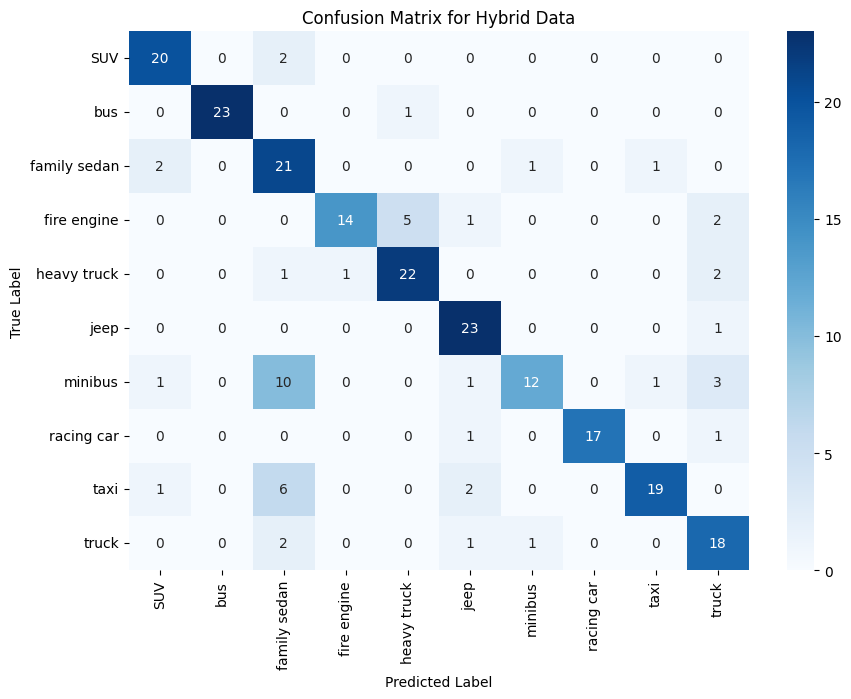

Epoch [10/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.1679, Accuracy=94.05%]


Epoch [10/20] on Hybrid Data, Loss: 0.1679, Accuracy: 94.05%
Validation Accuracy on Hybrid Data: 78.75%
              precision    recall  f1-score   support

         SUV       0.69      0.91      0.78        22
         bus       1.00      0.75      0.86        24
family sedan       0.61      0.68      0.64        25
 fire engine       0.95      0.82      0.88        22
 heavy truck       0.82      0.88      0.85        26
        jeep       0.76      0.92      0.83        24
     minibus       0.64      0.82      0.72        28
  racing car       1.00      0.74      0.85        19
        taxi       0.82      0.82      0.82        28
       truck       1.00      0.50      0.67        22

    accuracy                           0.79       240
   macro avg       0.83      0.78      0.79       240
weighted avg       0.82      0.79      0.79       240



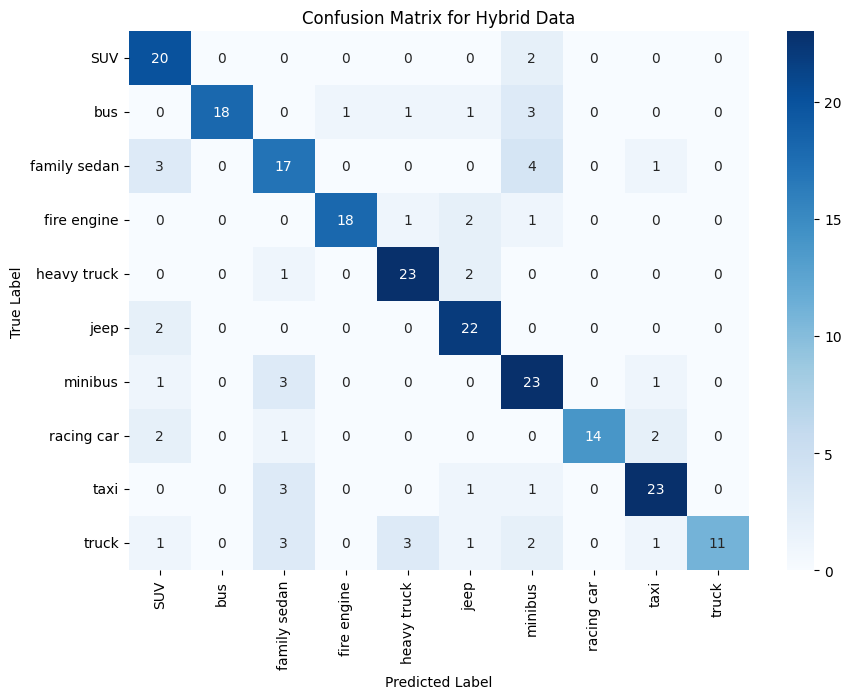

Epoch [11/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.2219, Accuracy=92.55%]


Epoch [11/20] on Hybrid Data, Loss: 0.2219, Accuracy: 92.55%
Validation Accuracy on Hybrid Data: 86.25%
              precision    recall  f1-score   support

         SUV       0.79      0.86      0.83        22
         bus       0.96      1.00      0.98        24
family sedan       0.80      0.80      0.80        25
 fire engine       1.00      0.77      0.87        22
 heavy truck       0.92      0.85      0.88        26
        jeep       0.91      0.88      0.89        24
     minibus       0.92      0.86      0.89        28
  racing car       0.81      0.89      0.85        19
        taxi       0.96      0.79      0.86        28
       truck       0.66      0.95      0.78        22

    accuracy                           0.86       240
   macro avg       0.87      0.86      0.86       240
weighted avg       0.88      0.86      0.86       240



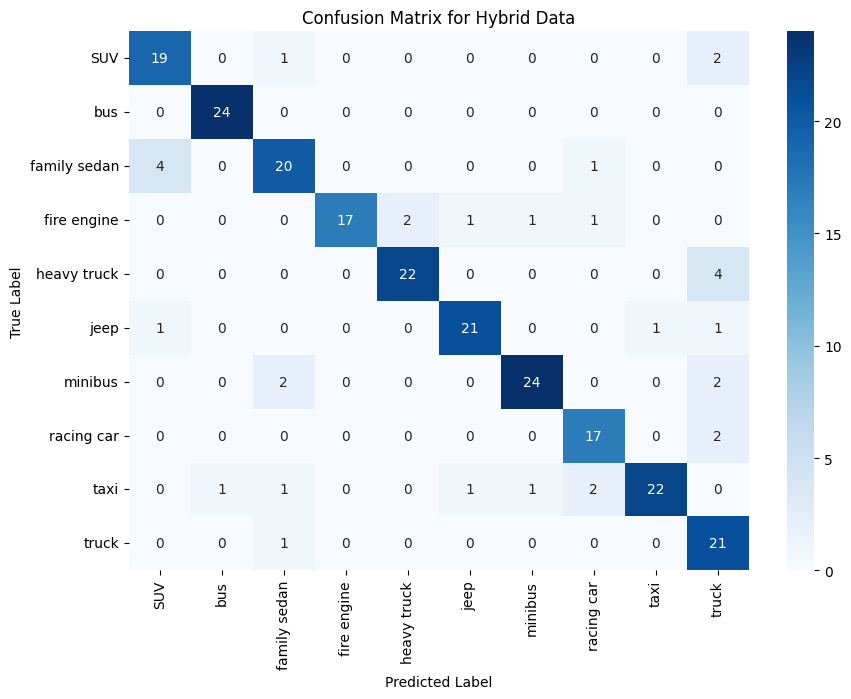

Epoch [12/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.1210, Accuracy=95.73%]


Epoch [12/20] on Hybrid Data, Loss: 0.1210, Accuracy: 95.73%
Validation Accuracy on Hybrid Data: 83.33%
              precision    recall  f1-score   support

         SUV       0.90      0.82      0.86        22
         bus       1.00      0.83      0.91        24
family sedan       0.62      0.80      0.70        25
 fire engine       0.94      0.73      0.82        22
 heavy truck       0.82      0.88      0.85        26
        jeep       0.88      0.96      0.92        24
     minibus       0.84      0.93      0.88        28
  racing car       0.93      0.74      0.82        19
        taxi       0.86      0.89      0.88        28
       truck       0.68      0.68      0.68        22

    accuracy                           0.83       240
   macro avg       0.85      0.83      0.83       240
weighted avg       0.85      0.83      0.83       240



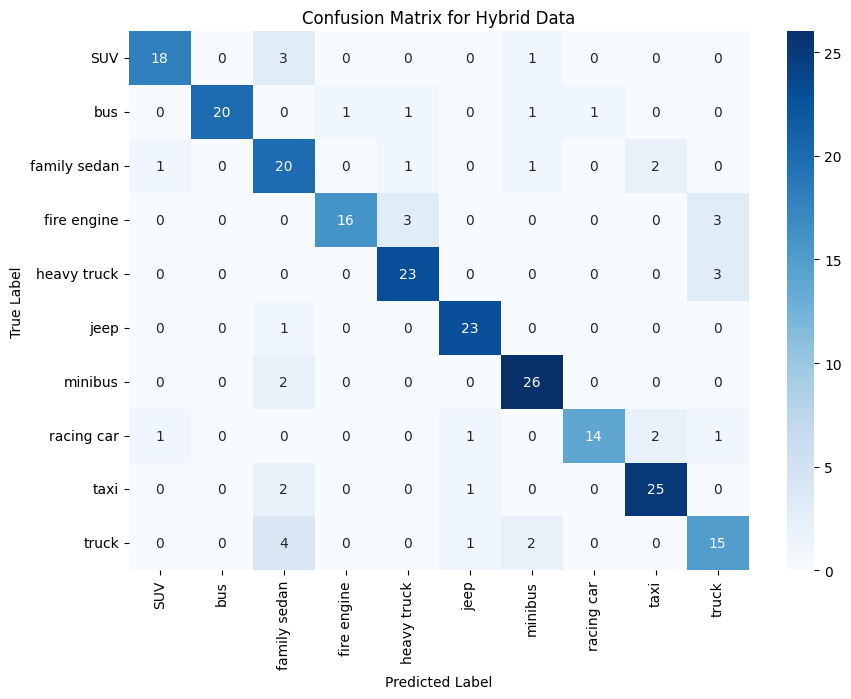

Epoch [13/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.1046, Accuracy=96.38%]


Epoch [13/20] on Hybrid Data, Loss: 0.1046, Accuracy: 96.38%
Validation Accuracy on Hybrid Data: 78.75%
              precision    recall  f1-score   support

         SUV       0.66      0.95      0.78        22
         bus       1.00      0.88      0.93        24
family sedan       0.76      0.64      0.70        25
 fire engine       0.88      0.64      0.74        22
 heavy truck       0.93      0.50      0.65        26
        jeep       0.88      0.88      0.88        24
     minibus       0.96      0.89      0.93        28
  racing car       0.93      0.74      0.82        19
        taxi       0.74      0.89      0.81        28
       truck       0.51      0.86      0.64        22

    accuracy                           0.79       240
   macro avg       0.82      0.79      0.79       240
weighted avg       0.83      0.79      0.79       240



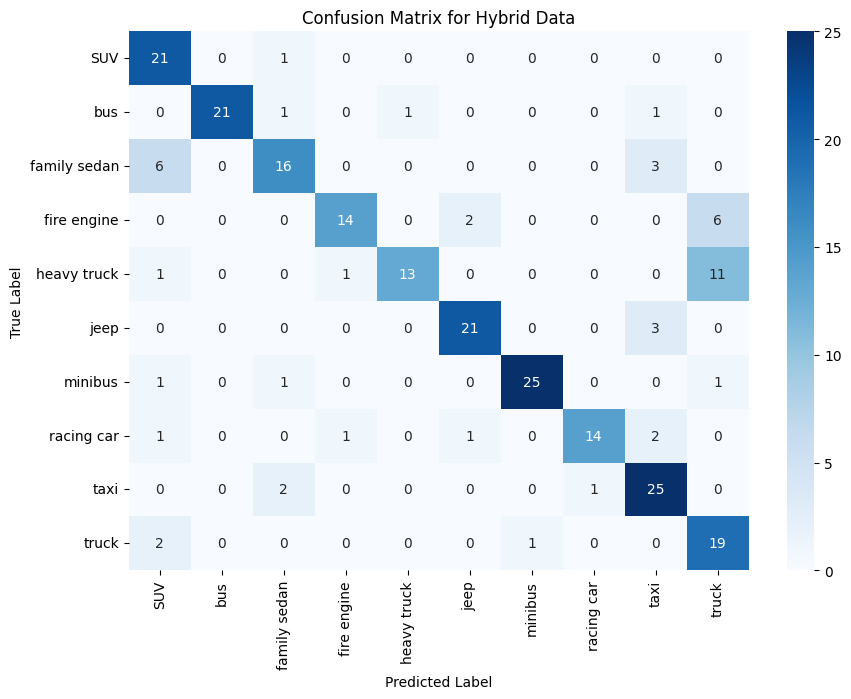

Epoch [14/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.1284, Accuracy=95.58%]


Epoch [14/20] on Hybrid Data, Loss: 0.1284, Accuracy: 95.58%
Validation Accuracy on Hybrid Data: 81.25%
              precision    recall  f1-score   support

         SUV       0.77      0.91      0.83        22
         bus       1.00      1.00      1.00        24
family sedan       0.58      0.88      0.70        25
 fire engine       1.00      0.64      0.78        22
 heavy truck       0.85      0.85      0.85        26
        jeep       0.95      0.75      0.84        24
     minibus       0.88      0.75      0.81        28
  racing car       1.00      0.74      0.85        19
        taxi       0.86      0.68      0.76        28
       truck       0.64      0.95      0.76        22

    accuracy                           0.81       240
   macro avg       0.85      0.81      0.82       240
weighted avg       0.85      0.81      0.82       240



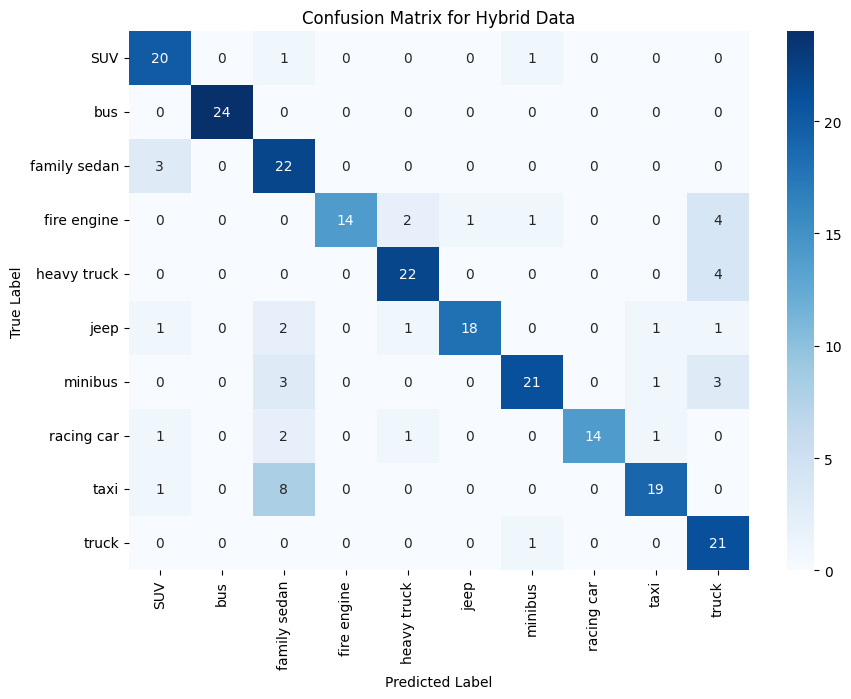

Epoch [15/20] on Hybrid Data: 100%|██████████| 129/129 [01:45<00:00,  1.22it/s, Loss=0.1052, Accuracy=96.29%]


Epoch [15/20] on Hybrid Data, Loss: 0.1052, Accuracy: 96.29%
Validation Accuracy on Hybrid Data: 82.08%
              precision    recall  f1-score   support

         SUV       0.94      0.68      0.79        22
         bus       0.83      1.00      0.91        24
family sedan       0.62      0.96      0.75        25
 fire engine       0.94      0.77      0.85        22
 heavy truck       0.78      0.81      0.79        26
        jeep       0.95      0.79      0.86        24
     minibus       0.83      0.86      0.84        28
  racing car       1.00      0.79      0.88        19
        taxi       0.83      0.71      0.77        28
       truck       0.78      0.82      0.80        22

    accuracy                           0.82       240
   macro avg       0.85      0.82      0.82       240
weighted avg       0.84      0.82      0.82       240



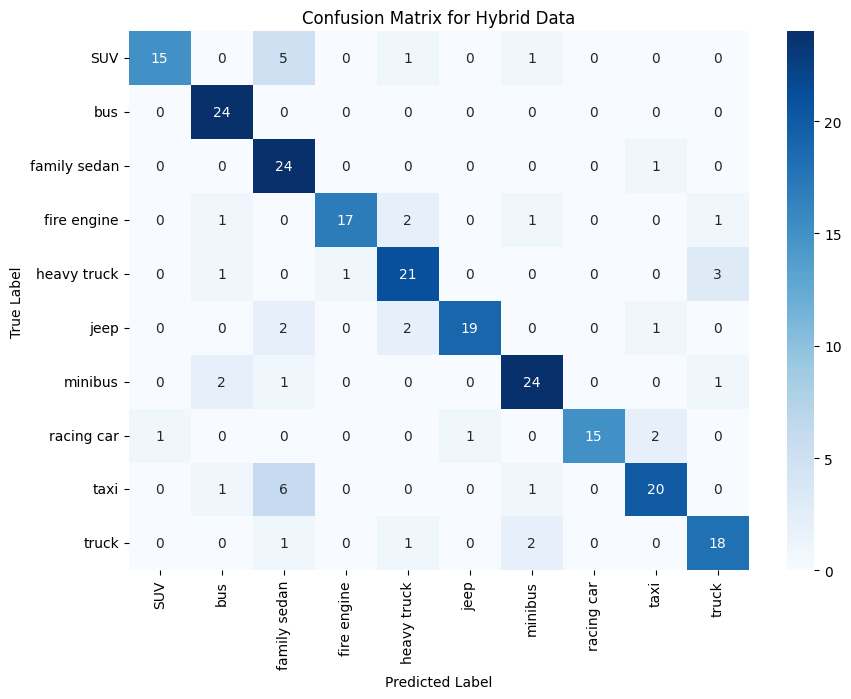

Epoch [16/20] on Hybrid Data: 100%|██████████| 129/129 [01:44<00:00,  1.23it/s, Loss=0.1240, Accuracy=95.78%]


Epoch [16/20] on Hybrid Data, Loss: 0.1240, Accuracy: 95.78%
Validation Accuracy on Hybrid Data: 85.00%
              precision    recall  f1-score   support

         SUV       0.83      0.91      0.87        22
         bus       0.83      1.00      0.91        24
family sedan       0.78      0.84      0.81        25
 fire engine       1.00      0.73      0.84        22
 heavy truck       0.90      0.69      0.78        26
        jeep       0.80      1.00      0.89        24
     minibus       0.96      0.79      0.86        28
  racing car       1.00      0.74      0.85        19
        taxi       0.89      0.89      0.89        28
       truck       0.69      0.91      0.78        22

    accuracy                           0.85       240
   macro avg       0.87      0.85      0.85       240
weighted avg       0.87      0.85      0.85       240



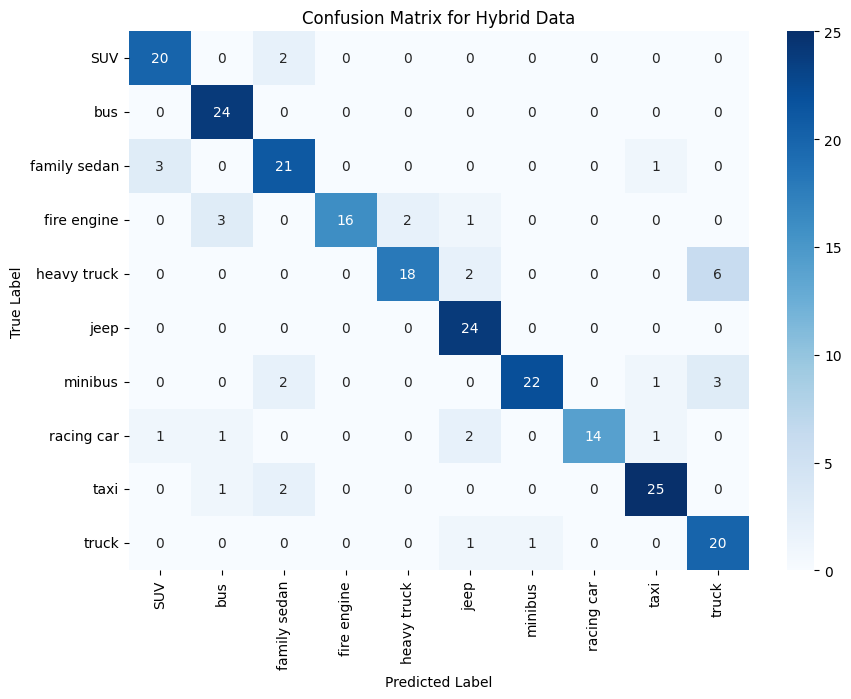

Epoch [17/20] on Hybrid Data: 100%|██████████| 129/129 [01:45<00:00,  1.22it/s, Loss=0.1137, Accuracy=96.02%]


Epoch [17/20] on Hybrid Data, Loss: 0.1137, Accuracy: 96.02%
Validation Accuracy on Hybrid Data: 77.50%
              precision    recall  f1-score   support

         SUV       0.73      0.86      0.79        22
         bus       1.00      0.79      0.88        24
family sedan       0.72      0.72      0.72        25
 fire engine       0.94      0.77      0.85        22
 heavy truck       0.83      0.58      0.68        26
        jeep       0.79      0.92      0.85        24
     minibus       0.84      0.75      0.79        28
  racing car       1.00      0.84      0.91        19
        taxi       0.89      0.61      0.72        28
       truck       0.48      1.00      0.65        22

    accuracy                           0.78       240
   macro avg       0.82      0.78      0.79       240
weighted avg       0.82      0.78      0.78       240



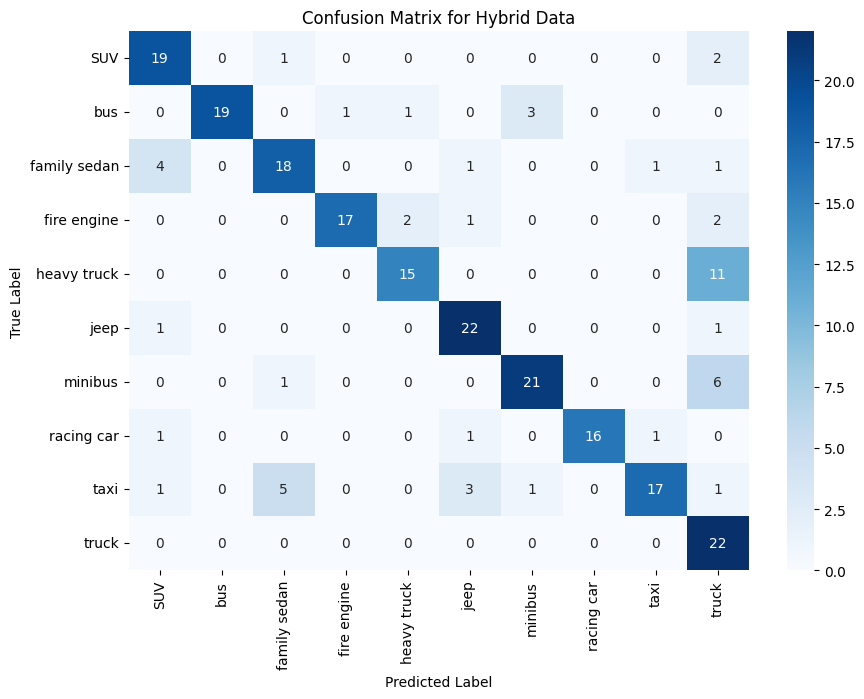

Epoch [18/20] on Hybrid Data: 100%|██████████| 129/129 [01:46<00:00,  1.21it/s, Loss=0.0924, Accuracy=96.94%]


Epoch [18/20] on Hybrid Data, Loss: 0.0924, Accuracy: 96.94%
Validation Accuracy on Hybrid Data: 88.33%
              precision    recall  f1-score   support

         SUV       0.81      0.95      0.88        22
         bus       0.92      1.00      0.96        24
family sedan       0.84      0.84      0.84        25
 fire engine       0.95      0.86      0.90        22
 heavy truck       0.95      0.73      0.83        26
        jeep       1.00      0.88      0.93        24
     minibus       0.90      0.93      0.91        28
  racing car       1.00      0.79      0.88        19
        taxi       0.89      0.89      0.89        28
       truck       0.70      0.95      0.81        22

    accuracy                           0.88       240
   macro avg       0.90      0.88      0.88       240
weighted avg       0.90      0.88      0.88       240



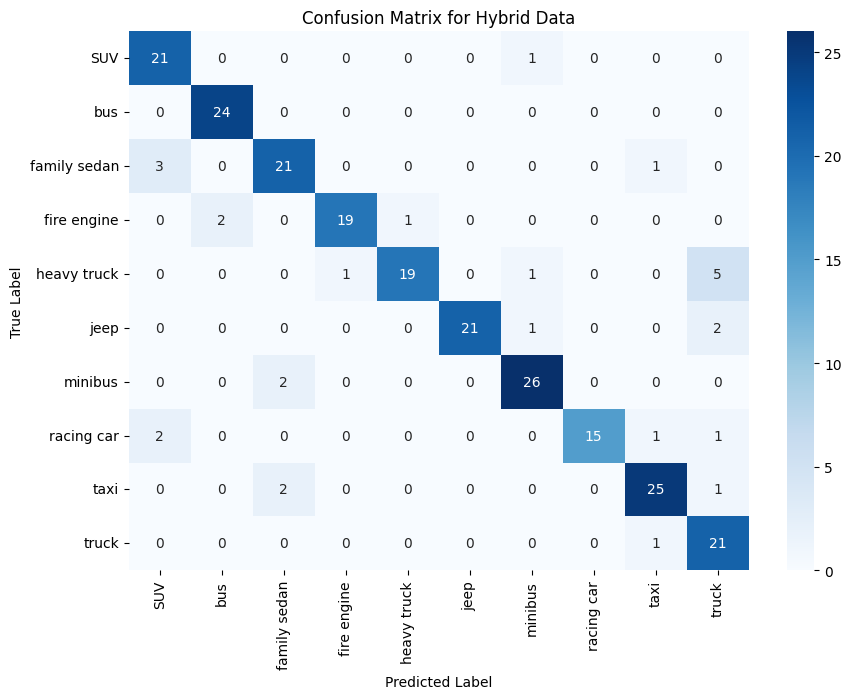

Epoch [19/20] on Hybrid Data: 100%|██████████| 129/129 [01:47<00:00,  1.20it/s, Loss=0.0624, Accuracy=98.11%]


Epoch [19/20] on Hybrid Data, Loss: 0.0624, Accuracy: 98.11%
Validation Accuracy on Hybrid Data: 87.50%
              precision    recall  f1-score   support

         SUV       0.78      0.95      0.86        22
         bus       1.00      0.96      0.98        24
family sedan       0.78      0.72      0.75        25
 fire engine       1.00      0.82      0.90        22
 heavy truck       0.88      0.88      0.88        26
        jeep       0.92      0.96      0.94        24
     minibus       0.96      0.82      0.88        28
  racing car       1.00      0.89      0.94        19
        taxi       0.82      0.96      0.89        28
       truck       0.71      0.77      0.74        22

    accuracy                           0.88       240
   macro avg       0.88      0.87      0.88       240
weighted avg       0.88      0.88      0.88       240



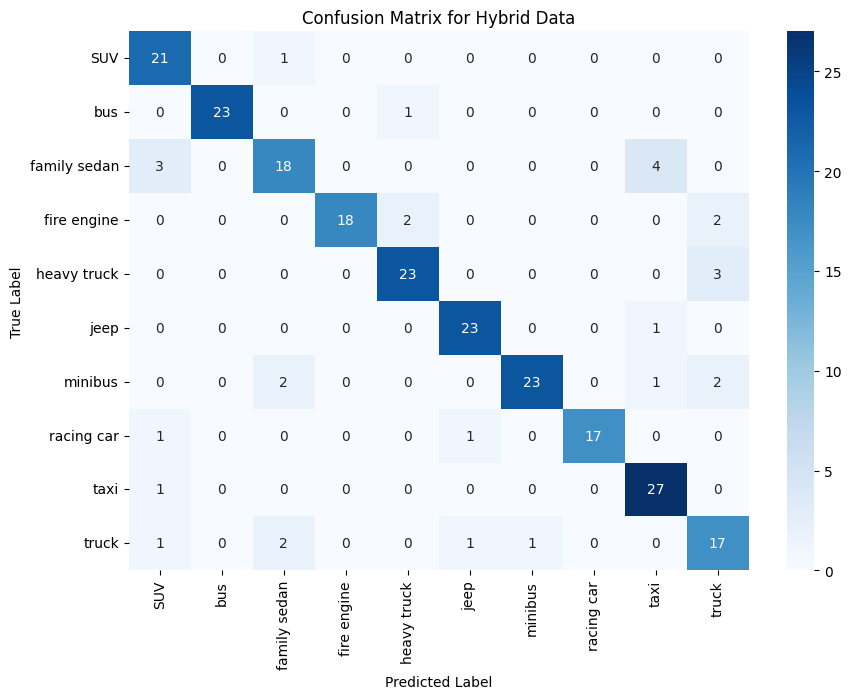

Epoch [20/20] on Hybrid Data: 100%|██████████| 129/129 [01:45<00:00,  1.22it/s, Loss=0.0903, Accuracy=96.97%]


Epoch [20/20] on Hybrid Data, Loss: 0.0903, Accuracy: 96.97%
Validation Accuracy on Hybrid Data: 80.00%
              precision    recall  f1-score   support

         SUV       0.68      0.95      0.79        22
         bus       0.96      0.92      0.94        24
family sedan       0.57      0.64      0.60        25
 fire engine       0.86      0.82      0.84        22
 heavy truck       0.91      0.77      0.83        26
        jeep       1.00      0.62      0.77        24
     minibus       0.85      0.82      0.84        28
  racing car       0.94      0.84      0.89        19
        taxi       0.77      0.71      0.74        28
       truck       0.70      0.95      0.81        22

    accuracy                           0.80       240
   macro avg       0.82      0.81      0.80       240
weighted avg       0.82      0.80      0.80       240



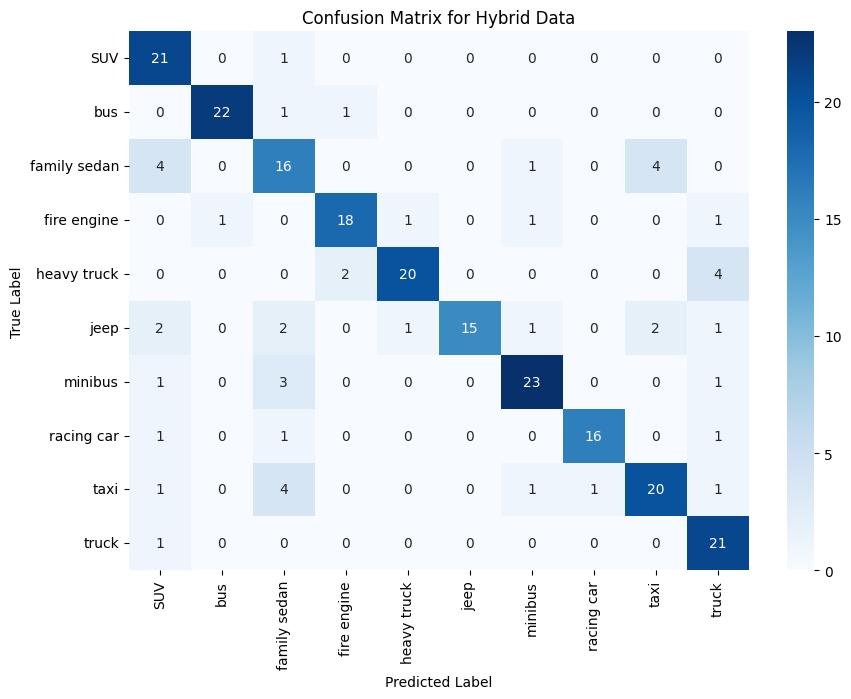

Evaluating real data model on test set...
Test Accuracy: 71.67%
              precision    recall  f1-score   support

         SUV       0.89      0.70      0.78        23
         bus       1.00      0.91      0.95        23
family sedan       0.62      0.87      0.73        23
 fire engine       0.95      0.67      0.78        27
 heavy truck       0.83      0.86      0.84        22
        jeep       1.00      0.29      0.45        24
     minibus       0.94      0.62      0.74        26
  racing car       0.34      1.00      0.51        22
        taxi       0.76      0.52      0.62        31
       truck       1.00      0.89      0.94        19

    accuracy                           0.72       240
   macro avg       0.83      0.73      0.74       240
weighted avg       0.83      0.72      0.73       240



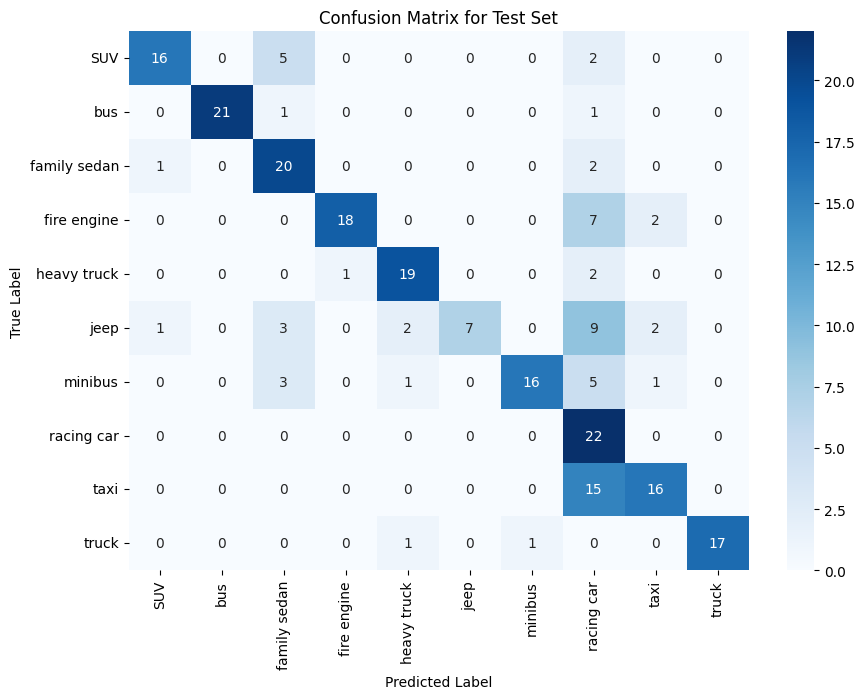

Evaluating hybrid data model on test set...
Test Accuracy: 88.33%
              precision    recall  f1-score   support

         SUV       0.88      0.91      0.89        23
         bus       0.92      0.96      0.94        23
family sedan       0.84      0.91      0.88        23
 fire engine       0.87      1.00      0.93        27
 heavy truck       1.00      0.68      0.81        22
        jeep       0.94      0.67      0.78        24
     minibus       0.89      0.92      0.91        26
  racing car       0.91      0.91      0.91        22
        taxi       1.00      0.87      0.93        31
       truck       0.68      1.00      0.81        19

    accuracy                           0.88       240
   macro avg       0.89      0.88      0.88       240
weighted avg       0.90      0.88      0.88       240



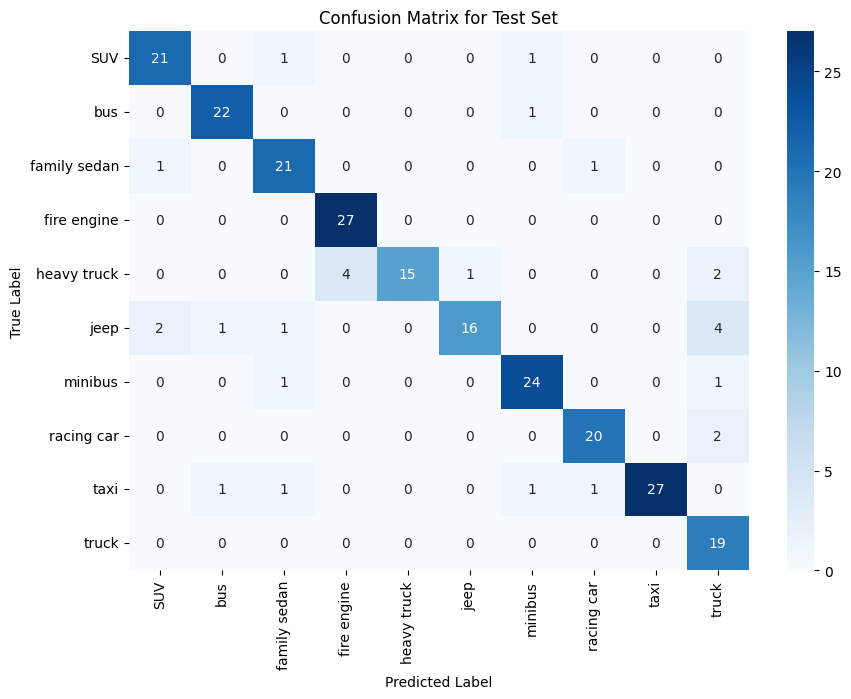

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import transforms, datasets, models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Define augmentation and normalization for synthetic and real datasets
augmentation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

real_data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
real_data = datasets.ImageFolder(root='/content/drive/MyDrive/trainvehicle', transform=real_data_transform)
synthetic_data = datasets.ImageFolder(root='/content/drive/MyDrive/vehicle_dataset', transform=augmentation_transform)

# Split real data into train, validation, and test sets (70% train, 15% validation, 15% test)
train_size = int(0.7 * len(real_data))
val_size = int(0.15 * len(real_data))
test_size = len(real_data) - train_size - val_size
real_train_data, real_val_data, real_test_data = random_split(real_data, [train_size, val_size, test_size])

# Define DataLoaders
batch_size = 32
train_loader_real = DataLoader(real_train_data, batch_size=batch_size, shuffle=True)
val_loader_real = DataLoader(real_val_data, batch_size=batch_size, shuffle=False)
test_loader_real = DataLoader(real_test_data, batch_size=batch_size, shuffle=False)  # Test DataLoader from real data

train_loader_synthetic = DataLoader(synthetic_data, batch_size=batch_size, shuffle=True)

# Hybrid dataset combining real and synthetic data
hybrid_data = ConcatDataset([real_train_data, synthetic_data])
train_loader_hybrid = DataLoader(hybrid_data, batch_size=batch_size, shuffle=True)

# Load a ResNet-18 model pretrained on ImageNet
num_classes = 10  # Assuming 10 vehicle classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to train the model
def train_model(model, train_loader, val_loader, epochs=20, device='cuda', dataset_name=""):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # TQDM progress bar for each epoch
        progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Epoch [{epoch+1}/{epochs}] on {dataset_name}')

        for batch_idx, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Update progress bar with batch loss and accuracy
            progress_bar.set_postfix({
                'Loss': f'{running_loss/(batch_idx+1):.4f}',
                'Accuracy': f'{100 * correct/total:.2f}%'
            })

        # Print epoch results
        print(f'Epoch [{epoch+1}/{epochs}] on {dataset_name}, Loss: {running_loss/len(train_loader):.4f}, '
              f'Accuracy: {100 * correct/total:.2f}%')

        # Validate after each epoch
        validate_model(model, val_loader, device, vehicle_classes, dataset_name)

# Function to validate the model
def validate_model(model, val_loader, device='cuda', class_names=None, dataset_name=""):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Collect predictions and true labels
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate accuracy
    accuracy = 100 * correct / total
    print(f'Validation Accuracy on {dataset_name}: {accuracy:.2f}%')

    # Generate classification report and confusion matrix
    if class_names is not None:
        print(classification_report(all_labels, all_preds, target_names=class_names))
        cm = confusion_matrix(all_labels, all_preds)
        plot_confusion_matrix(cm, classes=class_names, dataset_name=dataset_name)

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes=None, dataset_name=""):
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix for {dataset_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Vehicle classes (automatically inferred if using ImageFolder)
vehicle_classes = real_data.classes

# Copy the original model for each dataset (real, synthetic, hybrid)
model_real = models.resnet18(pretrained=True)
model_real.fc = nn.Linear(model_real.fc.in_features, num_classes)

model_synthetic = models.resnet18(pretrained=True)
model_synthetic.fc = nn.Linear(model_synthetic.fc.in_features, num_classes)

model_hybrid = models.resnet18(pretrained=True)
model_hybrid.fc = nn.Linear(model_hybrid.fc.in_features, num_classes)

# Move models to GPU
model_real = model_real.to(device)
model_synthetic = model_synthetic.to(device)
model_hybrid = model_hybrid.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Train on real data
optimizer = optim.Adam(model_real.parameters(), lr=0.001)
print("Training on Real Data...")
train_model(model_real, train_loader_real, val_loader_real, epochs=20, device=device, dataset_name="Real Data")

# Train on synthetic data
optimizer = optim.Adam(model_synthetic.parameters(), lr=0.001)
print("Training on Synthetic Data...")
train_model(model_synthetic, train_loader_synthetic, val_loader_real, epochs=20, device=device, dataset_name="Synthetic Data")

# Train on hybrid data
optimizer = optim.Adam(model_hybrid.parameters(), lr=0.001)
print("Training on Hybrid Data...")
train_model(model_hybrid, train_loader_hybrid, val_loader_real, epochs=20, device=device, dataset_name="Hybrid Data")

# Function to evaluate model performance on the test set
def evaluate_on_test_set(model, test_loader, device='cuda'):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Collect predictions and true labels
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')

    # Generate classification report and confusion matrix
    print(classification_report(all_labels, all_preds, target_names=vehicle_classes))
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm, classes=vehicle_classes, dataset_name="Test Set")

# After training, evaluate each model on the test set
print("Evaluating real data model on test set...")
evaluate_on_test_set(model_real, test_loader_real, device=device)

print("Evaluating hybrid data model on test set...")
evaluate_on_test_set(model_hybrid, test_loader_real, device=device)
